#Differential Isoform Usage

Identify isoforms with significantly shifted usage between cell types using a gene-level **Dirichlet-multinomial (DM)** likelihood-ratio test on the recollapsed isoform counts (one adj. p per gene, broadcast to its isoforms; signed per-isoform delta fraction). This replaces the earlier per-isoform Wilcoxon `rank_isoform_fractions` path, which has a testability bias that hides down-in-group isoforms (see CLAUDE.md "Per-isoform DIU volcano ... use gene-level DM").

In [1]:
import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import issparse
import warnings, os, sys, gc
warnings.filterwarnings('ignore')
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

gc.enable()

import importlib
import differential_isoform_fraction
importlib.reload(differential_isoform_fraction)

from differential_isoform_fraction import (
    rank_gene_isoform_usage_dm,
    plot_gene_isoform_dm_volcano,
)
from pyVolcano import plot_volcano
from add_classification import add_classification

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

BASEDIR = "./../pacbio"
H5AD_DIR = f"{BASEDIR}/h5ads"

popv_to_ts = pd.read_csv("./../csvs/popv_to_ts_celltype_mapping.csv")
ts_celltypes = pd.read_csv("./../csvs/ts_celltypes.csv")
popv_to_ts_map = dict(zip(popv_to_ts["popv_prediction"], popv_to_ts["ts_cell_ontology_class"]))
ts_broad_map = dict(zip(ts_celltypes["cell_ontology_class"], ts_celltypes["broad_cell_class"]))

# reload figure_paths: a live kernel caches FIG_MAP
import importlib
import figure_paths
importlib.reload(figure_paths)
from figure_paths import figpath  # routes figures/ -> figures/figureN/ via FIG_MAP



In [2]:
# preferred plot formatting
import matplotlib
import matplotlib.legend as _mlegend

# Font: Arial, with editable text in vector output
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial'] + matplotlib.rcParams['font.sans-serif']
# Mathtext (anything in $...$) otherwise falls back to DejaVu Sans, so Greek letters,
# superscripts and subscripts render in a different family from the surrounding Arial.
# "custom" + the four Arial families keeps the whole figure in one typeface.
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Arial'
matplotlib.rcParams['mathtext.it'] = 'Arial:italic'
matplotlib.rcParams['mathtext.bf'] = 'Arial:bold'

# Tunable spacing (points)
TICK_LEN = 2.0
TICK_LABEL_PAD = 1.5
AXIS_LABEL_PAD = 1.5
PANEL_TITLE_PAD = 3.0

plt.rcParams.update({
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "legend.labelspacing": 0.1,
    "legend.borderpad": 0.3,
    "legend.handletextpad": 0.2,
    "legend.title_fontsize": 6,
    "figure.titlesize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    "xtick.major.size": TICK_LEN,
    "ytick.major.size": TICK_LEN,
    "xtick.major.pad": TICK_LABEL_PAD,
    "ytick.major.pad": TICK_LABEL_PAD,
    "axes.labelpad": AXIS_LABEL_PAD,
    "axes.titlepad": PANEL_TITLE_PAD,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Legend-title weight has no rcParam -> make every legend title bold by default.
if not getattr(_mlegend.Legend, "_bold_title_patched", False):
    _orig_set_title = _mlegend.Legend.set_title
    def _bold_set_title(self, title, prop=None):
        res = _orig_set_title(self, title, prop=prop)
        self.get_title().set_fontweight("bold")
        return res
    _mlegend.Legend.set_title = _bold_set_title
    _mlegend.Legend._bold_title_patched = True

#1. Load data, merge cell types, filter to well-represented cell types

In [3]:
adata = sc.read_h5ad(f"{H5AD_DIR}/all_samples_pacbio_recollapsed_raw_counts_ensemblids_bc_anndata_preprocessed_with_isofrac.h5ad")
print(f"Loaded: {adata.shape[0]} cells x {adata.shape[1]} isoforms")
print(f"Isoform fraction layer present: {'isoform_fraction' in adata.layers}")

# Load cell type annotations explicitly and map to ontology classes
print(f"Unique cell ontology classes: {(adata.obs['cell_ontology_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['cell_ontology_class'].nunique() - 1} unique")
print(f"Unique broad cell classes: {(adata.obs['broad_cell_class'] != 'unknown').sum()} mapped, "
      f"{adata.obs['broad_cell_class'].nunique() - 1} unique")

# Load SQANTI3 classification (provides structural_category and other columns)
add_classification(adata, "./../csvs/all_samples_recollapsed_pigeon_classification_ensemblids.csv",
                   isoform_col="transcript_id", prefix="pigeon_", sep=",")

# Filter to cell types with >= 100 cells
ct_counts = adata.obs["cell_ontology_class"].value_counts()
valid_cts = ct_counts[ct_counts >= 100].index.tolist()
valid_cts = [ct for ct in valid_cts if ct != "unknown"]
print(f"Cell types with >= 100 cells: {len(valid_cts)}")
print(ct_counts[ct_counts >= 100])

adata = adata[adata.obs["cell_ontology_class"].isin(valid_cts)].copy()
print(f"After cell type filter: {adata.shape}")
gc.collect()

2026-09-09 19:49:33,992 INFO Reading classification from ./../csvs/all_samples_recollapsed_pigeon_classification_ensemblids.csv


Loaded: 203311 cells x 478192 isoforms
Isoform fraction layer present: True
Unique cell ontology classes: 203311 mapped, 143 unique
Unique broad cell classes: 203311 mapped, 33 unique


2026-09-09 19:49:56,361 INFO Classification table: 10200660 isoforms, columns ['chrom', 'strand', 'length', 'exons', 'structural_category', 'associated_gene', 'associated_transcript', 'ref_length', 'ref_exons', 'subcategory', 'FL', 'FSM_class', 'coding', 'predicted_NMD', 'isoform']
2026-09-09 19:49:56,362 WARNING Columns not found in classification file: {'filter_result'}
2026-09-09 19:50:04,841 INFO Matched 458961 / 478192 isoforms to classification
2026-09-09 19:50:10,415 INFO Added 14 columns; 458961 / 478192 isoforms annotated


Cell types with >= 100 cells: 92
cell_ontology_class
fibroblast                                              22832
stromal cell of ovary                                   19114
macrophage                                              14719
mesenchymal stem cell                                    8878
bladder urothelial cell                                  8751
                                                        ...  
naive thymus-derived cd4-positive, alpha-beta t cell      111
adventitial cell                                          108
intermediate monocyte                                     108
best4+ intestinal epithelial cell, human                  104
hematopoietic stem cell                                   101
Name: count, Length: 92, dtype: int64
After cell type filter: (201480, 478192)


1074

#2. Verify pre-computed isoform fractions

In [4]:
gene_col = "pigeon_associated_gene" if "pigeon_associated_gene" in adata.var.columns else "gene_names"
print(f"Gene column: {gene_col}")
print(f"Isoform fraction layer: nnz={adata.layers['isoform_fraction'].nnz}")

# `rank_gene_col` is defined HERE, not in the DM cell of section 3. That cell is the heavy one
# and is normally skipped on reruns (its DM body is commented out once the CSV exists), so
# anything downstream that relied on it -- the section 10 case studies -- died with
# NameError: rank_gene_col. This cell always runs, so the definition belongs in it.
rank_gene_col = "gene_name" if "gene_name" in adata.var.columns else gene_col
print(f"Gene column for ranking/case studies: {rank_gene_col}")

Gene column: pigeon_associated_gene
Isoform fraction layer: nnz=257381557
Gene column for ranking/case studies: gene_name


#3. Run differential isoform usage (gene-level Dirichlet-multinomial)

In [5]:
# Differential isoform usage via the gene-level Dirichlet-multinomial (DM) LRT,
# replacing the per-isoform Wilcoxon path (rank_isoform_fractions). The Wilcoxon
# path has a testability bias that never tests down-in-group isoforms (their gene
# fails the two-sided floor) -> one-sided volcano ( "Per-isoform DIU
# volcano ... use gene-level DM"). DM tests each gene's isoform-COUNT composition
# (raw counts in adata.X, NOT the isoform_fraction layer): one BH p-value per gene
# broadcast to its isoforms, with a signed per-isoform delta_fraction so both
# gaining and losing isoforms are captured.
#
# PARALLELISM (like 06_04): each broad cell class is ONE one-vs-rest DM test run
# SERIALLY inside (n_threads=1), and the cell classes run in PARALLEL processes --
# the coarse granularity the per-gene MLE wants (its inner per-gene pool is
# overhead-bound; ~40-65 ms/gene < fork+IPC cost). One-vs-rest can't use
# rank_gene_isoform_usage_dm_by_celltype (that subsets to one split's cells, leaving
# no "rest"), so we fan the one-vs-rest loop across processes here, mirroring its
# fork + BLAS-pinned-to-1 setup. MEMORY: each worker slices the FULL matrix
# (group + rest = all cells), so peak RAM ~= _n_jobs x object -> keep _n_jobs modest
# unless on bigmem (raise toward the core count there).
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor
try:
    from threadpoolctl import threadpool_limits as _threadpool_limits
except Exception:
    from contextlib import nullcontext
    def _threadpool_limits(*_a, **_k):
        return nullcontext()

# (redefined here only so this cell stands alone; the canonical definition is in section 2,
#  which always runs -- see the note there)
rank_gene_col = "gene_name" if "gene_name" in adata.var.columns else gene_col
broad_classes = [c for c in adata.obs["broad_cell_class"].unique() if c != "unknown"]
_n_jobs = min(16, len(os.sched_getaffinity(0)), len(broad_classes))  # matches the 32-core batch allocation; clamps to actual cores
print(f"Running DM DIU for {len(broad_classes)} broad cell classes | serial per class, "
      f"{_n_jobs} classes in parallel (heavy — run on a compute/bigmem node)")

# # fork-shared state so workers inherit `adata` via copy-on-write (only the class name is sent)
# _DIU_STATE = {"adata": adata, "gene_col": rank_gene_col}
# def _dm_one_vs_rest(_ct):
#     try:
#         return rank_gene_isoform_usage_dm(
#             _DIU_STATE["adata"],
#             groupby="broad_cell_class",
#             group=_ct,
#             reference="rest",
#             counts_layer=None,          # raw isoform counts in adata.X (not fractions)
#             gene_col=_DIU_STATE["gene_col"],
#             min_cells=50,
#             min_isoforms=2,
#             n_threads=1,                # SERIAL inside; parallelism is across cell classes
#         )
#     except ValueError as _e:
#         print(f"  skip {_ct}: {_e}")
#         return None

# try:
#     if _n_jobs <= 1 or len(broad_classes) <= 1:
#         raise RuntimeError("serial")
#     with _threadpool_limits(1), ProcessPoolExecutor(
#             max_workers=_n_jobs, mp_context=_mp.get_context("fork")) as _pool:
#         dm_parts = list(_pool.map(_dm_one_vs_rest, broad_classes))
# except Exception as _pe:
#     if not str(_pe) == "serial":
#         print(f"  parallel path failed ({_pe!r}); falling back to serial")
#     dm_parts = [_dm_one_vs_rest(_ct) for _ct in broad_classes]

# dm_parts = [d for d in dm_parts if d is not None and len(d)]
# dm_all = pd.concat(dm_parts, ignore_index=True)
# print(f"DM DIU complete: {dm_all['group'].nunique()} cell classes, "
#       f"{len(dm_all)} gene-isoform rows across {dm_all['gene'].nunique()} genes.")

Running DM DIU for 30 broad cell classes | serial per class, 8 classes in parallel (heavy — run on a compute/bigmem node)


In [6]:
# # Save the DM DIU results and read them back, so downstream analysis runs off the
# # saved table (the heavy DM compute above can then be skipped on reruns).
DM_ALL_CSV = "./../csvs/04_11_dm_diu_per_broad_cell_class.csv"
# dm_all.to_csv(DM_ALL_CSV, index=False)
# print(f"Saved DM DIU -> {DM_ALL_CSV} ({len(dm_all)} rows)")

In [7]:
# Read back so downstream cells consume the saved file
dm_all = pd.read_csv(DM_ALL_CSV)
# keep the boolean 'tested' column intact across the CSV round-trip
if dm_all["tested"].dtype == object:
    dm_all["tested"] = dm_all["tested"].astype(str).str.lower().isin(["true", "1", "1.0"])
print(f"Loaded DM DIU <- {DM_ALL_CSV} ({len(dm_all)} rows)")

Loaded DM DIU <- ./../csvs/04_11_dm_diu_per_broad_cell_class.csv (8143446 rows)


#4. Extract significant DIU events

In [8]:
# Significant DIU = isoforms whose GENE is DM-significant (adj p < 0.01) AND whose
# own isoform-usage shift is sizeable (|delta_fraction| > 0.1). The DM p-value is
# per gene (identical across its isoforms); delta_fraction is per isoform & signed,
# so both up- and down-in-group isoforms survive (no one-sided Wilcoxon artefact).
diu_df = dm_all[
    dm_all["tested"]
    & (dm_all["dm_pvals_adj"] < 0.01)
    & (dm_all["delta_fraction"].abs() > 0.1)
].copy()
# 'pvals_adj' alias so any downstream code keyed on the Wilcoxon name still works.
diu_df["pvals_adj"] = diu_df["dm_pvals_adj"]
print(f"Significant DIU events (DM gene adj p < 0.01, |delta_frac| > 0.1): {len(diu_df)}")
print(f"Unique isoforms: {diu_df['names'].nunique()}")
print(f"Unique genes: {diu_df['gene'].nunique()}")
diu_df.head(10)

Significant DIU events (DM gene adj p < 0.01, |delta_frac| > 0.1): 150962
Unique isoforms: 53659
Unique genes: 16057


,group,gene,names,n_isoforms,n_cells_group,n_cells_ref,dm_stat,dm_pval,dm_pvals_adj,tv_distance,mean_fraction,mean_fraction_reference,delta_fraction,tested,pvals_adj
151,myeloid leukocyte,NDUFAF7,PB.15029.15003,82,666,8057,642.549302,4.439558e-116,4.001455e-115,0.301424,0.000000,0.154676,-0.154676,True,4.001455e-115
219,myeloid leukocyte,HS3ST1,ENST00000002596.6,9,376,3440,98.031774,3.932589e-17,9.125982e-17,0.224038,0.551684,0.750717,-0.199033,True,9.125982e-17
222,myeloid leukocyte,HS3ST1,PB.41704.4190,9,376,3440,98.031774,3.932589e-17,9.125982e-17,0.224038,0.391933,0.191483,0.200450,True,9.125982e-17
228,myeloid leukocyte,CYP51A1,ENST00000003100.13,29,1548,17577,298.809047,1.398622e-46,5.837413e-46,0.181897,0.457967,0.619425,-0.161458,True,5.837413e-46
230,myeloid leukocyte,CYP51A1,ENST00000450723.5,29,1548,17577,298.809047,1.398622e-46,5.837413e-46,0.181897,0.380609,0.256789,0.123821,True,5.837413e-46
285,myeloid leukocyte,STPG1,ENST00000337248.9,46,116,3736,93.616081,1.839734e-08,3.180915e-08,0.356992,0.504310,0.327147,0.177163,True,3.180915e-08
352,myeloid leukocyte,TMEM176A,ENST00000004103.8,45,4895,23199,1718.361432,0.000000e+00,0.000000e+00,0.253019,0.299657,0.428931,-0.129274,True,0.000000e+00
355,myeloid leukocyte,TMEM176A,ENST00000468689.2,45,4895,23199,1718.361432,0.000000e+00,0.000000e+00,0.253019,0.420664,0.219213,0.201451,True,0.000000e+00
458,myeloid leukocyte,PDK4,ENST00000473301.1,34,3057,23022,328.736402,5.435443e-52,2.452766e-51,0.120055,0.181849,0.289020,-0.107171,True,2.452766e-51
708,myeloid leukocyte,PRSS21,ENST00000005995.8,19,154,2435,112.714443,2.513591e-15,5.506862e-15,0.326352,0.158009,0.309526,-0.151517,True,5.506862e-15


#5. DIU events per cell type

In [9]:
diu_per_ct = diu_df.groupby("group").size().sort_values(ascending=False)
print("Significant DIU events per cell type:")
print(diu_per_ct)

Significant DIU events per cell type:
group
male germ cell                  25646
transitional epithelial cell     9051
stromal cell                     8405
epithelial cell of lung          8190
t cell                           7888
myeloid leukocyte                7714
fibroblast                       7388
intestinal epithelial cell       6945
lymphocyte of b lineage          6634
stratified epithelial cell       6229
kidney epithelial cell           5813
glandular epithelial cell        5615
stem cell                        5287
contractile cell                 4547
epithelial cell                  3753
endothelial cell                 3709
innate lymphoid cell             3708
vestibular dark cell             3217
endo-epithelial cell             3080
ciliated epithelial cell         2416
duct epithelial cell             2333
erythroid lineage cell           2273
granulocyte                      2156
hematopoietic cell               1989
melanocyte                       1895
ecto-e

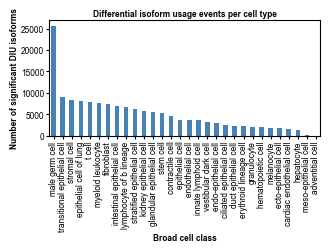

In [10]:
fig, ax = plt.subplots(figsize=(3.5, 1.5))
diu_per_ct.plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("Number of significant DIU isoforms")
ax.set_xlabel("Broad cell class")
ax.set_title("Differential isoform usage events per cell type")
plt.xticks(rotation=90)
plt.savefig(figpath("04_11_diu_events_per_cell_type.pdf"))
plt.show()

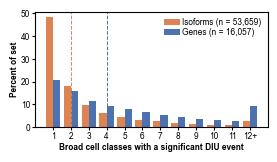

isoforms: 53,659 | median 2 cell classes | 48.3% in exactly one
genes   : 16,057 | median 4 cell classes | 20.5% in exactly one
dashed lines mark the two medians


In [11]:
# Breadth of the DIU signal: in how many broad cell classes does each significant ISOFORM turn
# up, and each significant GENE? Both on one panel because the contrast between them is the claim:
# isoforms are largely class-specific while the genes carrying them recur across classes, i.e.
# cell types redistribute usage within a shared set of genes rather than switching genes on/off.
# Plotted as a percent of each set, not a count, because there are ~3x more isoforms than genes
# and raw counts would not be comparable on one axis.
CAP = 12          # last bar aggregates ">= CAP" so the sparse tail does not stretch the axis

_iso_n = diu_df.groupby("names")["group"].nunique()
_gene_n = diu_df.groupby("gene")["group"].nunique()

def _pct(v):
    c = v.clip(upper=CAP).value_counts().reindex(range(1, CAP + 1), fill_value=0).sort_index()
    return c / len(v) * 100

_pi, _pg = _pct(_iso_n), _pct(_gene_n)
_x = np.arange(1, CAP + 1)
_w = 0.4

fig, ax = plt.subplots(figsize=(3.0, 1.5))
ax.bar(_x - _w / 2, _pi.values, width=_w, color="#dd8452",
       label=f"Isoforms (n = {len(_iso_n):,})")
ax.bar(_x + _w / 2, _pg.values, width=_w, color="#4c72b0",
       label=f"Genes (n = {len(_gene_n):,})")
ax.axvline(_iso_n.median(), color="#dd8452", ls="--", lw=0.7)
ax.axvline(_gene_n.median(), color="#4c72b0", ls="--", lw=0.7)
ax.set_xticks(_x)
ax.set_xticklabels([str(i) for i in _x[:-1]] + [f"{CAP}+"])
ax.set_xlabel("Broad cell classes with a significant DIU event")
ax.set_ylabel("Percent of set")
ax.legend(frameon=False)
fig.savefig(figpath("04_11_diu_breadth_isoform_vs_gene.pdf"), bbox_inches="tight")
plt.show()

print(f"isoforms: {len(_iso_n):,} | median {_iso_n.median():.0f} cell classes | "
      f"{(_iso_n == 1).mean() * 100:.1f}% in exactly one")
print(f"genes   : {len(_gene_n):,} | median {_gene_n.median():.0f} cell classes | "
      f"{(_gene_n == 1).mean() * 100:.1f}% in exactly one")
print("dashed lines mark the two medians")

#5b. Is isoform usage independent of gene-level expression?

The DM tests each gene's isoform **composition conditional on that gene's per-cell total**
(`_dm_loglik` conditions on `n_i`, and `_dm_fit` drops zero-count cells), so by construction it
cannot be a repackaged expression test. This cell checks that empirically instead of asserting
it: for every (gene, broad cell class) it puts the gene-level one-vs-rest log fold-change next
to the strongest isoform-usage shift for the same gene in the same class.

Both sides are one-vs-rest by `broad_cell_class` and both are computed on the same cell
population (cell types with >= 100 cells), so the join is like-for-like. The claim
"isoforms encode identity independently of gene-level expression" predicts a tall column of
DIU-significant points sitting at log2FC ~ 0 -- genes whose *amount* does not change but whose
isoform *choice* does.

(gene, cell class) pairs: DIU 250,159 | joined to DE 250,159 | unmatched 0 (of which 829 are multi-locus '+' names)

DIU call: DM gene padj < 0.01 AND max |delta fraction| > 0.1
DE call : padj < 0.05 AND |log2FC| > 0.5
  205,224 pairs clear padj alone; 145,649 also clear the fold-change floor (59,575 dropped by it)

significant DIU events: 81,939
  in genes NOT differentially expressed in that class: 28,469 (34.7%)   <- the independence number
quadrant
DE only     92179
neither     76041
both        53470
DIU only    28469

Spearman(|log2FC|, max |delta fraction|) = +0.148  (near 0 = orthogonal axes)

sensitivity of the independence % to a |log2FC| gate on the DE call:
  |log2FC| > 0     -> DE 205,224 | DIU in non-DE genes  12,138 ( 14.8%)
  |log2FC| > 0.1   -> DE 203,704 | DIU in non-DE genes  12,412 ( 15.1%)
  |log2FC| > 0.25  -> DE 187,813 | DIU in non-DE genes  16,385 ( 20.0%)
  |log2FC| > 0.5   -> DE 145,649 | DIU in non-DE genes  28,469 ( 34.7%)   <- the panels use this row
  |lo

2026-09-09 19:50:38,096 WARNING findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
2026-09-09 19:50:38,096 WARNING findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive


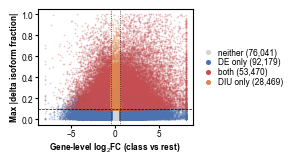

In [12]:
# DIU vs DE orthogonality, one point per (gene, broad cell class).
DE_CSV      = "./../csvs/04_12_marker_genes.csv"   # written by 04_12 (rank_genes_groups, gene level)
DIU_PADJ, DIU_DELTA = 0.01, 0.1    # DIU call (same cuts that define diu_df in section 4)
DE_PADJ,  DE_LFC    = 0.05, 0.5    # DE call: adjusted p AND a minimum |log2FC|
# ONE DE definition, used by EVERY DIU-vs-DE panel in this notebook: the scatter and the
# 1D density below, the hexbin, and section 9. Edit these two numbers and all four move.

# gene-level DIU: the DM p-value is per gene (already broadcast across its isoforms), and the
# effect size is the strongest single-isoform shift that gene shows in that class
diu_gene = (dm_all[dm_all["tested"]]
            .groupby(["gene", "group"], observed=True)
            .agg(dm_padj=("dm_pvals_adj", "first"),
                 max_abs_delta=("delta_fraction", lambda s: s.abs().max()))
            .reset_index())

de = pd.read_csv(DE_CSV).rename(columns={"names": "gene", "pvals_adj": "de_padj",
                                         "logfoldchanges": "de_lfc"})
de["group"] = de["group"].astype(str)
diu_gene["group"] = diu_gene["group"].astype(str)
m = diu_gene.merge(de[["gene", "group", "de_lfc", "de_padj"]], on=["gene", "group"], how="inner")

# honest denominator: multi-locus names ("AJM1+PHPT1") exist only in the ensemblids object and
# cannot match the gene-level object, so they drop out of the inner join
_lost = len(diu_gene) - len(m)
_multi = int(diu_gene["gene"].astype(str).str.contains(r"\+").sum())
print(f"(gene, cell class) pairs: DIU {len(diu_gene):,} | joined to DE {len(m):,} "
      f"| unmatched {_lost:,} (of which {_multi:,} are multi-locus '+' names)")

# NOTE two-sided DE cut: 04_12's markers_gene_sig keeps logfoldchanges > 0 only, so using it
# directly would score down-regulated genes as "not DE" and inflate the orthogonality claim.
m["diu_sig"] = (m["dm_padj"] < DIU_PADJ) & (m["max_abs_delta"] > DIU_DELTA)
# The fold-change floor makes the independence number ANTI-conservative: a gene at log2FC 0.8
# with padj 1e-20 is plainly differentially expressed, and a gate that files it under "not DE"
# lets it count as evidence for independence. The sweep printed below shows how far the headline
# % moves with the gate -- read it before quoting any single number.
m["de_sig"] = (m["de_padj"] < DE_PADJ) & (m["de_lfc"].abs() > DE_LFC)
m["quadrant"] = np.select(
    [m.diu_sig & ~m.de_sig, m.diu_sig & m.de_sig, ~m.diu_sig & m.de_sig],
    ["DIU only", "both", "DE only"], default="neither")
_p_only = int((m["de_padj"] < DE_PADJ).sum())
print(f"\nDIU call: DM gene padj < {DIU_PADJ} AND max |delta fraction| > {DIU_DELTA}")
print(f"DE call : padj < {DE_PADJ} AND |log2FC| > {DE_LFC}")
print(f"  {_p_only:,} pairs clear padj alone; {int(m['de_sig'].sum()):,} also clear the fold-change "
      f"floor ({_p_only - int(m['de_sig'].sum()):,} dropped by it)")

_n_diu = int(m["diu_sig"].sum())
_n_iso_only = int((m.diu_sig & ~m.de_sig).sum())
print(f"\nsignificant DIU events: {_n_diu:,}")
print(f"  in genes NOT differentially expressed in that class: {_n_iso_only:,} "
      f"({_n_iso_only/max(_n_diu,1)*100:.1f}%)   <- the independence number")
print(m["quadrant"].value_counts().to_string())
_rho = m["de_lfc"].abs().corr(m["max_abs_delta"], method="spearman")
print(f"\nSpearman(|log2FC|, max |delta fraction|) = {_rho:+.3f}  (near 0 = orthogonal axes)")

# how much does the headline number depend on where "DE" is drawn? sweep the fold-change
# gate we deliberately did NOT apply. If independence only appears at a large gate, it was
# an artefact of the gate rather than a property of the data.
print("\nsensitivity of the independence % to a |log2FC| gate on the DE call:")
for _g in sorted({0.0, 0.1, 0.25, 0.5, 1.0, DE_LFC}):
    _de = (m["de_padj"] < DE_PADJ) & (m["de_lfc"].abs() > _g)
    _io = int((m.diu_sig & ~_de).sum())
    print(f"  |log2FC| > {_g:<5g} -> DE {int(_de.sum()):>7,} | "
          f"DIU in non-DE genes {_io:>7,} ({_io/max(_n_diu,1)*100:5.1f}%)"
          f"{'   <- the panels use this row' if _g == DE_LFC else ''}")

_pal = {"neither": "lightgrey", "DE only": "#4c72b0", "DIU only": "#dd8452", "both": "#c44e52"}
fig, ax = plt.subplots(figsize=(2.0, 1.5))
for q in ("neither", "DE only", "both", "DIU only"):      # DIU-only drawn last, stays visible
    d = m[m["quadrant"] == q]
    ax.scatter(d["de_lfc"].clip(-8, 8), d["max_abs_delta"], s=1.5, alpha=0.3,
               linewidths=0, c=_pal[q], label=f"{q} ({len(d):,})")
ax.axhline(DIU_DELTA, color="black", lw=0.5, ls="--")
ax.axvline(-DE_LFC, color="black", lw=0.5, ls=":")
ax.axvline(DE_LFC, color="black", lw=0.5, ls=":")
ax.set_xlabel("Gene-level log$_2$FC (class vs rest)")
ax.set_ylabel("Max |delta isoform fraction|")
# ax.set_title(f"{_n_iso_only/max(_n_diu,1)*100:.0f}% of DIU events are in genes that are not DE",
#              pad=PANEL_TITLE_PAD)
leg = ax.legend(fontsize=6, markerscale=3, 
                loc=6, bbox_to_anchor = (1.0,0.5), frameon=False)
for h in leg.legend_handles:
    h.set_alpha(1.0)
fig.savefig(figpath("04_11_diu_vs_de_orthogonality.pdf"), bbox_inches="tight")
plt.show()

median |log2FC|  all tested 0.632 | DIU-significant 0.795
DIU events with |log2FC| < 0.5: 34.7%
KS on |log2FC| (all vs DIU): D = 0.085, p = 0.00e+00
  NOTE with n this large even a trivial shift is significant -- read D (effect size),
  not p. D near 0 means the DIU set is drawn from the same log2FC distribution.


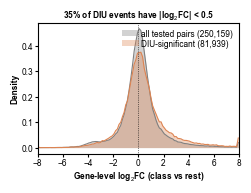

In [13]:
# 1D version of the same claim, without the overplotting of the scatter above: if DIU events
# were really an expression effect in disguise, their log2FC distribution would sit in the
# tails relative to all tested (gene, cell class) pairs. Overlapping curves = orthogonal axes.
from scipy.stats import ks_2samp

_all = m["de_lfc"].to_numpy(dtype=float)
_diu = m.loc[m["diu_sig"], "de_lfc"].to_numpy(dtype=float)
_all = _all[np.isfinite(_all)]
_diu = _diu[np.isfinite(_diu)]

# shared bins so the two densities are directly comparable; clip only for display, the
# statistics below use the unclipped values
LFC_LIM = 8
_bins = np.linspace(-LFC_LIM, LFC_LIM, 121)
_d_all, _ = np.histogram(np.clip(_all, -LFC_LIM, LFC_LIM), bins=_bins, density=True)
_d_diu, _ = np.histogram(np.clip(_diu, -LFC_LIM, LFC_LIM), bins=_bins, density=True)
_ctr = (_bins[:-1] + _bins[1:]) / 2

fig, ax = plt.subplots(figsize=(2.6, 1.7))
ax.fill_between(_ctr, _d_all, color="grey", alpha=0.35, lw=0,
                label=f"all tested pairs ({len(_all):,})")
ax.plot(_ctr, _d_all, color="grey", lw=0.8)
ax.fill_between(_ctr, _d_diu, color="#dd8452", alpha=0.35, lw=0,
                label=f"DIU-significant ({len(_diu):,})")
ax.plot(_ctr, _d_diu, color="#dd8452", lw=0.8)
ax.axvline(0, color="black", lw=0.5, ls=":")
ax.set_xlabel("Gene-level log$_2$FC (class vs rest)")
ax.set_ylabel("Density")
ax.set_xlim(-LFC_LIM, LFC_LIM)
ax.legend(fontsize=6, frameon=False, loc="upper right")

# put a number on the overlap rather than eyeballing the curves
_ks = ks_2samp(np.abs(_all), np.abs(_diu))
_frac_flat = float((np.abs(_diu) < DE_LFC).mean())
ax.set_title(f"{_frac_flat*100:.0f}% of DIU events have |log$_2$FC| < {DE_LFC:g}",
             pad=PANEL_TITLE_PAD)

print(f"median |log2FC|  all tested {np.median(np.abs(_all)):.3f} | "
      f"DIU-significant {np.median(np.abs(_diu)):.3f}")
print(f"DIU events with |log2FC| < {DE_LFC:g}: {_frac_flat*100:.1f}%")
print(f"KS on |log2FC| (all vs DIU): D = {_ks.statistic:.3f}, p = {_ks.pvalue:.2e}")
print("  NOTE with n this large even a trivial shift is significant -- read D (effect size),")
print("  not p. D near 0 means the DIU set is drawn from the same log2FC distribution.")

fig.savefig(figpath("04_11_diu_vs_de_logfc_density.pdf"), bbox_inches="tight")
plt.show()

hexbin over 81,939 DIU-significant (gene, cell class) pairs (32.8% of 250,159 tested)
  in genes NOT DE: 34.7%  <- the claim | also DE-significant: 65.3%
  of which, failing the fold-change floor |log2FC| <= 0.5: 34.7%
  Spearman(|log2FC|, max |delta|) within the DIU set: +0.230
  ^ this is the dependence the 1D density cannot show: if it is near 0, the size of the
    isoform shift is unrelated to the size of the expression change.


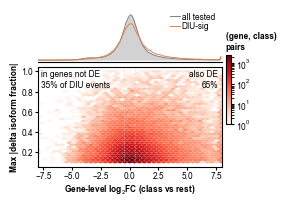

In [14]:
# Joint view of the same comparison, kept readable by (a) restricting the hexbin to the
# DIU-significant pairs -- the subject of the claim, and a small minority of all pairs, so a
# density over everything would render them as empty cells -- and (b) log-scaling the counts.
# DE call: padj < DE_PADJ AND |log2FC| > DE_LFC, set in the section-5b cell and shared
# by the scatter, the 1D density, this hexbin and section 9 alike.
# The grey marginal on top is the log2FC density of ALL tested pairs, as the reference the
# DIU set is being compared against. Recovers the isoform effect-size axis that the 1D
# density collapses away.
_sig = m[m["diu_sig"]]
_x = np.clip(_sig["de_lfc"].to_numpy(dtype=float), -LFC_LIM, LFC_LIM)
_y = _sig["max_abs_delta"].to_numpy(dtype=float)
_ok = np.isfinite(_x) & np.isfinite(_y)
_x, _y = _x[_ok], _y[_ok]

fig = plt.figure(figsize=(2.5, 2.0))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2], hspace=0.06)
ax_m = fig.add_subplot(gs[0])          # marginal reference
ax = fig.add_subplot(gs[1], sharex=ax_m)

# reference marginal: every tested pair, so the hexbin's x-spread can be read against it
_ref = m["de_lfc"].to_numpy(dtype=float)
_ref = _ref[np.isfinite(_ref)]
_bins = np.linspace(-LFC_LIM, LFC_LIM, 121)
_dref, _ = np.histogram(np.clip(_ref, -LFC_LIM, LFC_LIM), bins=_bins, density=True)
_dsig, _ = np.histogram(_x, bins=_bins, density=True)
_ctr = (_bins[:-1] + _bins[1:]) / 2
ax_m.fill_between(_ctr, _dref, color="grey", alpha=0.35, lw=0)
ax_m.plot(_ctr, _dref, color="grey", lw=0.7, label="all tested")
ax_m.plot(_ctr, _dsig, color="#dd8452", lw=0.7, label="DIU-sig")
ax_m.set_yticks([])
ax_m.tick_params(labelbottom=False, length=0)
for sp in ("top", "right", "left"):
    ax_m.spines[sp].set_visible(False)
ax_m.legend(fontsize=6, frameon=False, loc=4, bbox_to_anchor = (1.0, 0.5),
            handlelength=1.2)

hb = ax.hexbin(_x, _y, gridsize=38, bins="log", cmap="Reds", linewidths=0,
               extent=(-LFC_LIM, LFC_LIM, float(np.nanmin(_y)), float(np.nanmax(_y))))
# +-DE_LFC IS a real boundary here: this panel uses the padj + fold-change DE call, so
# points inside these lines fail the fold-change floor and count as "not DE".
ax.axvline(-DE_LFC, color="lightgrey", lw=0.5, ls=":")
ax.axvline(DE_LFC, color="lightgrey", lw=0.5, ls=":")
ax.set_xlabel("Gene-level log$_2$FC (class vs rest)")
ax.set_ylabel("Max |delta isoform fraction|")
ax.set_xlim(-LFC_LIM, LFC_LIM)

# quadrant shares WITHIN the DIU-significant set (that is what the panel is restricted to)
_n = len(_sig)
_flat = float((_sig["de_lfc"].abs() <= DE_LFC).mean())
_de_sig_share = float(_sig["de_sig"].mean())
_indep = 1.0 - _de_sig_share          # THE claim: DIU events in genes that are not DE
# Lead with the claim. Note the |log2FC| share below is now a COMPONENT of the DE call,
# not independent of it: "not DE" here means failing padj OR failing the fold-change
# floor, so that share is one of the two ways a pair lands in the not-DE group.
ax.text(0.02, 0.97, f"in genes not DE\n{_indep*100:.0f}% of DIU events",
        transform=ax.transAxes, ha="left", va="top", fontsize=6, linespacing=1.3)
ax.text(0.98, 0.97, f"also DE\n{_de_sig_share*100:.0f}%", transform=ax.transAxes,
        ha="right", va="top", fontsize=6, linespacing=1.3)

cb = fig.colorbar(hb, ax=[ax_m, ax], fraction=0.03, shrink=0.45, pad=0.02, aspect=12)
cb.ax.set_title("(gene, class)\npairs", fontsize=6, loc="left", pad=4)
cb.ax.tick_params(labelsize=6, length=2)

print(f"hexbin over {_n:,} DIU-significant (gene, cell class) pairs "
      f"({_n/len(m)*100:.1f}% of {len(m):,} tested)")
print(f"  in genes NOT DE: {_indep*100:.1f}%  <- the claim | also DE-significant: {_de_sig_share*100:.1f}%")
print(f"  of which, failing the fold-change floor |log2FC| <= {DE_LFC:g}: {_flat*100:.1f}%")
print(f"  Spearman(|log2FC|, max |delta|) within the DIU set: "
      f"{_sig['de_lfc'].abs().corr(_sig['max_abs_delta'], method='spearman'):+.3f}")
print("  ^ this is the dependence the 1D density cannot show: if it is near 0, the size of the")
print("    isoform shift is unrelated to the size of the expression change.")

fig.savefig(figpath("04_11_diu_vs_de_hexbin.pdf"), bbox_inches="tight")
plt.show()

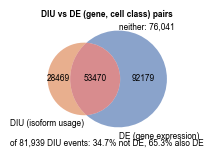

universe: 250,159 (gene, cell class) pairs | DE call padj < 0.05, |log2FC| > 0.5
  DIU only 28,469 | both 53,470 | DE only 92,179 | neither 76,041
  hexbin annotations reproduced: not DE 34.7%, also DE 65.3%
  Jaccard(DIU, DE) = 0.307


In [15]:
# The two numbers the hexbin annotates, drawn as sets. The hexbin is restricted to the
# DIU-significant pairs and reports "in genes not DE" / "also DE" as shares OF THAT SET -- those
# are exactly the DIU-only region and the overlap below, so this panel turns those two
# percentages into counts and shows what they are percentages of.
# Same DE call as everything else in this notebook (DE_PADJ / DE_LFC, set in section 5b).
from matplotlib_venn import venn2

if "m" not in globals() or not {"diu_sig", "de_sig"} <= set(m.columns):
    raise NameError("run section 5b (the orthogonality cell) first -- it builds `m` and the "
                    "diu_sig / de_sig calls")

_n_diu = int(m["diu_sig"].sum())
_n_de = int(m["de_sig"].sum())
_both = int((m.diu_sig & m.de_sig).sum())
_diu_only, _de_only = _n_diu - _both, _n_de - _both
_neither = len(m) - _diu_only - _de_only - _both

fig, ax = plt.subplots(figsize=(2.0, 1.5))
v = venn2(subsets=(_diu_only, _de_only, _both),
          set_labels=("DIU (isoform usage)", "DE (gene expression)"), ax=ax)
ax.set_axis_off()          # no data axes on a Venn
# colours match the section-5b quadrant palette so the two panels read together
for _pid, _col in (("10", "#dd8452"), ("01", "#4c72b0"), ("11", "#c44e52")):
    _p = v.get_patch_by_id(_pid)
    if _p is not None:
        _p.set_color(_col); _p.set_alpha(0.65); _p.set_edgecolor("none")
    _l = v.get_label_by_id(_pid)
    if _l is not None:
        _l.set_fontsize(6)
for _t in v.set_labels:
    if _t is not None:
        _t.set_fontsize(6)

# the hexbin's two annotations, restated as shares of the DIU set
ax.text(0.5, -0.02, f"of {_n_diu:,} DIU events: {_diu_only/max(_n_diu,1)*100:.1f}% not DE, "
                    f"{_both/max(_n_diu,1)*100:.1f}% also DE",
        transform=ax.transAxes, ha="center", va="top", fontsize=6)
# a Venn cannot show the pairs in neither set, so state them rather than let the circles
# imply the universe is DIU + DE
ax.text(0.99, 0.99, f"neither: {_neither:,}", transform=ax.transAxes,
        ha="right", va="top", fontsize=6)
ax.set_title("DIU vs DE (gene, cell class) pairs", pad=PANEL_TITLE_PAD)
fig.savefig(figpath("04_11_diu_de_venn.pdf"), bbox_inches="tight")
plt.show()

print(f"universe: {len(m):,} (gene, cell class) pairs | DE call padj < {DE_PADJ}, |log2FC| > {DE_LFC}")
print(f"  DIU only {_diu_only:,} | both {_both:,} | DE only {_de_only:,} | neither {_neither:,}")
print(f"  hexbin annotations reproduced: not DE {_diu_only/max(_n_diu,1)*100:.1f}%, "
      f"also DE {_both/max(_n_diu,1)*100:.1f}%")
print(f"  Jaccard(DIU, DE) = {_both/max(_n_diu + _n_de - _both, 1):.3f}")

#6. Top DIU isoforms per cell type

90 isoforms across 30 broad cell classes (top 3 each, gains only)
wrote /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/04_11_dm_diu_dotplot_top_per_cell_class.pdf


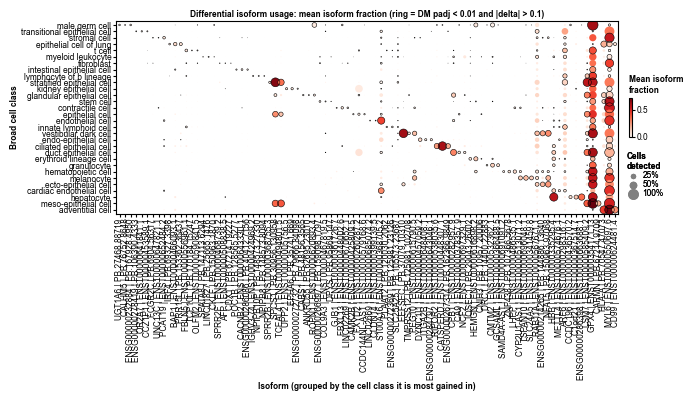

                       group                        gene              names  delta_fraction  dm_pvals_adj
            adventitial cell                       HLA-A     PB.70547.47073        0.545580  7.936900e-58
            adventitial cell                        MYL6  ENST00000550697.6        0.514537  3.312028e-35
            adventitial cell                        CD99  ENST00000624481.4        0.427599  1.312569e-66
    cardiac endothelial cell                         HBB  ENST00000335295.4        0.782383 1.232251e-187
    cardiac endothelial cell                      METTL4  ENST00000574676.1        0.725532  4.978351e-42
    cardiac endothelial cell                        ARF6  ENST00000298316.7        0.705331  1.982929e-33
    ciliated epithelial cell                      RIPOR2  ENST00000538035.6        0.913291 2.470897e-134
    ciliated epithelial cell                    CATSPERD  ENST00000448307.1        0.900553 5.587441e-308
    ciliated epithelial cell             ENSG0

In [16]:
# Dotplot of the top DIU isoforms per broad cell class (replaces the single all-classes
# DM volcano). Drawn directly in matplotlib rather than via sc.pl.dotplot so the layout
# matches the delta-fraction dotplot in the next cell exactly. Channels are the scanpy
# ones: COLOUR = mean isoform fraction within the cell class, SIZE = fraction of that
# class's cells in which the isoform is detected at all.
TOP_N_PER_CLASS = 3          # isoforms shown per cell class
GAINS_ONLY      = True       # True -> isoforms GAINED in the class (delta > 0), marker-style
DOT_MAX         = 60.0       # points^2 for "detected in 100% of the class's cells"
SIG_PADJ        = 0.01       # ring drawn on DM-significant (isoform, class) pairs
SIG_DELTA       = 0.1

top_cts = diu_per_ct.index.tolist()   # kept for downstream cells (e.g. grouped bars)

# Rank each class's significant DIU isoforms by the size of its usage shift. Assign each
# isoform to the ONE class where it shifts most (dedupe first, then take the top N per
# class) so no isoform appears as a column twice and every class still gets N slots.
_sig_sel = diu_df[diu_df["delta_fraction"] > 0] if GAINS_ONLY else diu_df.assign(
    _absd=diu_df["delta_fraction"].abs())
_sortcol = "delta_fraction" if GAINS_ONLY else "_absd"
_sig_sel = (_sig_sel.sort_values(_sortcol, ascending=False)
                    .drop_duplicates("names", keep="first"))
_top = _sig_sel.groupby("group", observed=True).head(TOP_N_PER_CLASS)

class_order = [c for c in top_cts if c in set(_top["group"])]
var_dict = {c: (_top.loc[_top["group"] == c]
                .sort_values(_sortcol, ascending=False)["names"].tolist())
            for c in class_order}
iso_ids = [i for v in var_dict.values() for i in v]
print(f"{len(iso_ids)} isoforms across {len(class_order)} broad cell classes "
      f"(top {TOP_N_PER_CLASS} each, {'gains only' if GAINS_ONLY else 'by |delta|'})")

# label columns "GENE | isoform" - raw ENST/PB ids alone are unreadable on an axis.
# Some annotations carry several symbols joined by "+" (a locus assigned more than one
# gene); keep the first so the axis label stays readable.
_gene_of = {n: str(g).split("+")[0].strip() for n, g in zip(_top["names"], _top["gene"])}
_label = {i: f"{_gene_of.get(i, '?')} | {i}" for i in iso_ids}
_labels = [_label[i] for i in iso_ids]

# small subset (cells x ~TOP_N*classes isoforms) so both dotplots are cheap
sub = adata[adata.obs["broad_cell_class"].isin(class_order), iso_ids].copy()
sub.var_names = pd.Index(_labels)
sub.obs["broad_cell_class"] = pd.Categorical(
    sub.obs["broad_cell_class"].astype(str), categories=class_order)

# --- colour: mean isoform fraction per (class, isoform), averaged over ALL the class's
# cells (not only the detecting ones) - the sc.pl.dotplot default.
# --- size: fraction of the class's cells in which the isoform is detected.
_frac = sub.layers["isoform_fraction"]
_frac = _frac.tocsr() if issparse(_frac) else _frac
mean_f = pd.DataFrame(0.0, index=class_order, columns=iso_ids)
det = pd.DataFrame(0.0, index=class_order, columns=iso_ids)
for _c in class_order:
    _m = (sub.obs["broad_cell_class"].astype(str) == _c).values
    if _m.sum() == 0:
        continue
    _blk = _frac[_m, :]
    mean_f.loc[_c] = np.asarray(_blk.mean(axis=0)).ravel()
    det.loc[_c] = np.asarray((_blk > 0).sum(axis=0)).ravel() / _m.sum()

# DM significance per (class, isoform), for the ring overlay
_sel = dm_all[dm_all["names"].isin(iso_ids) & dm_all["group"].isin(class_order)]
_dlt = (_sel.pivot_table(index="group", columns="names", values="delta_fraction",
                         aggfunc="first").reindex(index=class_order, columns=iso_ids))
_pad = (_sel.pivot_table(index="group", columns="names", values="dm_pvals_adj",
                         aggfunc="first").reindex(index=class_order, columns=iso_ids))

X, Y = np.meshgrid(np.arange(len(iso_ids)), np.arange(len(class_order)))
M, S = mean_f.to_numpy(dtype=float), det.to_numpy(dtype=float) * DOT_MAX
_ok = np.isfinite(M)
_vmax = float(np.nanmax(M)) or 0.1

fig, ax = plt.subplots(figsize=(6.75, 2.5))
_pts = ax.scatter(X[_ok], Y[_ok], s=S[_ok], c=M[_ok], cmap="Reds",
                  vmin=0, vmax=_vmax, linewidths=0)
_sig = (_ok & (_pad.to_numpy(dtype=float) < SIG_PADJ)
        & (np.abs(_dlt.to_numpy(dtype=float)) > SIG_DELTA))
ax.scatter(X[_sig], Y[_sig], s=S[_sig], facecolors="none", edgecolors="black", linewidths=0.4)

# # per-class column blocks + group labels above, mirroring the scanpy bracket layout
# _edge = 0
# for _c in class_order:
#     _n = len(var_dict[_c])
#     if _edge:
#         ax.axvline(_edge - 0.5, color="lightgrey", linewidth=0.5)
#     ax.text(_edge + (_n - 1) / 2, len(class_order) - 0.35, _c, ha="center", va="bottom",
#             fontsize=6, rotation=90)
#     _edge += _n

ax.set_xticks(range(len(iso_ids)))
ax.set_xticklabels(_labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(class_order)))
ax.set_yticklabels(class_order, fontsize=6)
ax.set_xlim(-0.6, len(iso_ids) - 0.4)
ax.set_ylim(-0.6, len(class_order) - 0.4)
ax.set_xlabel("Isoform (grouped by the cell class it is most gained in)")
ax.set_ylabel("Broad cell class")
ax.invert_yaxis()

cb = fig.colorbar(_pts, ax=ax, fraction=0.02, shrink=0.2, pad=0.02, aspect=12)
cb.ax.set_title("Mean isoform\nfraction", fontsize=6, loc="left", pad=4)
cb.ax.tick_params(labelsize=6, length=2)

_handles = [plt.scatter([], [], s=f * DOT_MAX, c="grey", linewidths=0) for f in (0.25, 0.5, 1.0)]
_leg = ax.legend(_handles, ["25%", "50%", "100%"], title="Cells\ndetected",
                 loc="center left", bbox_to_anchor=(1.00, 0.2), labelspacing=0.0,
                 frameon=False, borderpad=0.2)
ax.add_artist(_leg)
ax.set_title(f"Differential isoform usage: mean isoform fraction (ring = DM padj < {SIG_PADJ} "
             f"and |delta| > {SIG_DELTA})", pad=PANEL_TITLE_PAD)

_out = figpath("04_11_dm_diu_dotplot_top_per_cell_class.pdf")
fig.savefig(_out, bbox_inches="tight")
print(f"wrote {_out}")
plt.show()

# the isoforms drawn, for reference
print(_top.sort_values(["group", _sortcol], ascending=[True, False])[
      ["group", "gene", "names", "delta_fraction", "dm_pvals_adj"]].to_string(index=False))

wrote /oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks/figures/suppfigure8/04_11_dm_diu_dotplot_delta_fraction_top_per_cell_class.pdf


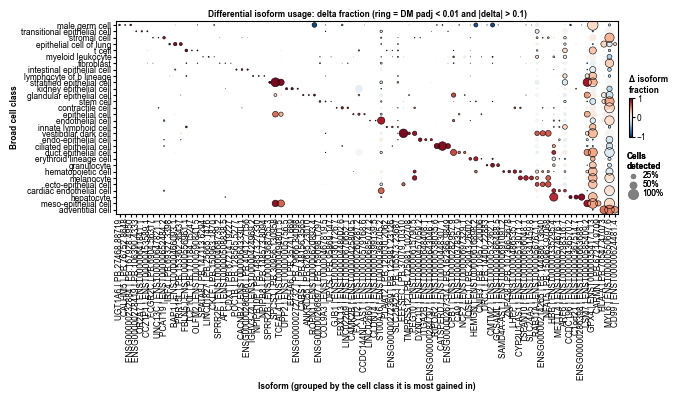

grid: 30 cell classes x 90 isoforms | 422 DM-significant pairs | 1849 untested pairs blank


In [17]:
# Same dotplot layout, but COLOUR = signed delta isoform fraction (class - rest) rather
# than the within-class mean fraction. sc.pl.dotplot cannot draw this: it derives colour
# by averaging the expression matrix, whereas delta_fraction is a per-(isoform, class)
# statistic that lives in dm_all. So the grid is drawn directly, keeping the scanpy
# conventions - dot size = fraction of the class's cells with the isoform detected,
# per-class column blocks, group labels above.
#
# Reuses iso_ids / class_order / var_dict / _label / sub from the cell above, so both
# plots show exactly the SAME isoforms and can be read side by side.
DOT_MAX      = 60.0     # points^2 for "detected in 100% of the class's cells"
SIG_PADJ     = 0.01     # ring drawn on DM-significant (isoform, class) pairs
SIG_DELTA    = 0.1

_labels = [_label[i] for i in iso_ids]

# --- colour: delta_fraction for every (class, isoform) pair, not just the significant ones
_sel = dm_all[dm_all["names"].isin(iso_ids) & dm_all["group"].isin(class_order)]
delta = (_sel.pivot_table(index="group", columns="names", values="delta_fraction",
                          aggfunc="first").reindex(index=class_order, columns=iso_ids))
padj = (_sel.pivot_table(index="group", columns="names", values="dm_pvals_adj",
                         aggfunc="first").reindex(index=class_order, columns=iso_ids))

# --- size: fraction of each class's cells in which the isoform is detected
_frac = sub.layers["isoform_fraction"]
_frac = _frac.tocsr() if issparse(_frac) else _frac
det = pd.DataFrame(0.0, index=class_order, columns=iso_ids)
for _c in class_order:
    _m = (sub.obs["broad_cell_class"].astype(str) == _c).values
    if _m.sum() == 0:
        continue
    det.loc[_c] = np.asarray((_frac[_m, :] > 0).sum(axis=0)).ravel() / _m.sum()

X, Y = np.meshgrid(np.arange(len(iso_ids)), np.arange(len(class_order)))
D, S = delta.to_numpy(dtype=float), det.to_numpy(dtype=float) * DOT_MAX
_ok = np.isfinite(D)                      # an isoform is not tested in every class
_vmax = float(np.nanmax(np.abs(D))) or 0.1

fig, ax = plt.subplots(figsize=(6.75, 2.5))
_pts = ax.scatter(X[_ok], Y[_ok], s=S[_ok], c=D[_ok], cmap="RdBu_r",
                  vmin=-_vmax, vmax=_vmax, linewidths=0)
_sig = _ok & (padj.to_numpy(dtype=float) < SIG_PADJ) & (np.abs(D) > SIG_DELTA)
ax.scatter(X[_sig], Y[_sig], s=S[_sig], facecolors="none", edgecolors="black", linewidths=0.4)

# # per-class column blocks + group labels above, mirroring the scanpy bracket layout
# _edge = 0
# for _c in class_order:
#     _n = len(var_dict[_c])
#     if _edge:
#         ax.axvline(_edge - 0.5, color="lightgrey", linewidth=0.5)
#     ax.text(_edge + (_n - 1) / 2, len(class_order) - 0.35, _c, ha="center", va="bottom",
#             fontsize=6, rotation=90)
#     _edge += _n

ax.set_xticks(range(len(iso_ids)))
ax.set_xticklabels(_labels, rotation=90, fontsize=6)
ax.set_yticks(range(len(class_order)))
ax.set_yticklabels(class_order, fontsize=6)
ax.set_xlim(-0.6, len(iso_ids) - 0.4)
ax.set_ylim(-0.6, len(class_order) - 0.4)
ax.set_xlabel("Isoform (grouped by the cell class it is most gained in)")
ax.set_ylabel("Broad cell class")
ax.invert_yaxis()

cb = fig.colorbar(_pts, ax=ax, fraction=0.02, shrink = 0.2, pad=0.02, aspect=12)
cb.ax.set_title("\u0394 isoform\nfraction", fontsize=6, loc="left", pad=4)
cb.ax.tick_params(labelsize=6, length=2)

_handles = [plt.scatter([], [], s=f * DOT_MAX, c="grey", linewidths=0) for f in (0.25, 0.5, 1.0)]
_leg = ax.legend(_handles, ["25%", "50%", "100%"], title="Cells\ndetected",
                 loc="center left", bbox_to_anchor=(1.00, 0.2), labelspacing=0.0,
                 frameon=False, borderpad=0.2)
ax.add_artist(_leg)
ax.set_title(f"Differential isoform usage: delta fraction (ring = DM padj < {SIG_PADJ} "
             f"and |delta| > {SIG_DELTA})", pad=PANEL_TITLE_PAD)

_out = figpath("04_11_dm_diu_dotplot_delta_fraction_top_per_cell_class.pdf")
fig.savefig(_out, bbox_inches="tight")
print(f"wrote {_out}")
plt.show()

print(f"grid: {len(class_order)} cell classes x {len(iso_ids)} isoforms | "
      f"{int(_sig.sum())} DM-significant pairs | {int((~_ok).sum())} untested pairs blank")

#8. Categorize DIU isoforms by structural category

In [18]:
# Merge structural category info into DIU results
var_info = adata.var[["pigeon_structural_category"]].copy()
var_info.index.name = "isoform_id"
diu_merged = diu_df.merge(var_info, left_on="names", right_index=True, how="left")

cat_counts = diu_merged["pigeon_structural_category"].value_counts().sort_values(ascending=True)
print("Structural category of DIU isoforms:")
print(cat_counts)

# Are DIU events more FSM/ISM switches or novel upregulation?
diu_merged["is_novel"] = diu_merged["pigeon_structural_category"].isin(
    ["novel_in_catalog", "novel_not_in_catalog"]
)
novel_frac = diu_merged.groupby("group")["is_novel"].mean().sort_values(ascending=False)


Structural category of DIU isoforms:
pigeon_structural_category
moreJunctions                 12
antisense                    115
intergenic                   632
fusion                       682
genic                       1083
novel_in_catalog            7989
novel_not_in_catalog       14450
incomplete-splice_match    56952
full-splice_match          62803
Name: count, dtype: int64


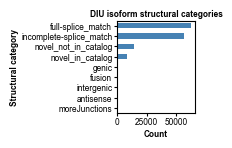

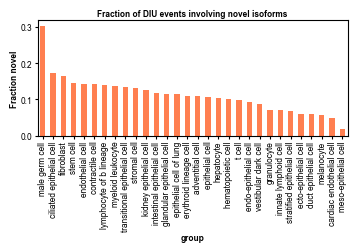

In [19]:
fig1, ax1 = plt.subplots(figsize=(1.0, 1.2))
cat_counts.plot(kind="barh", ax=ax1, color="steelblue")
ax1.set_title("DIU isoform structural categories")
ax1.set_ylabel("Structural category")
ax1.set_xlabel("Count")
plt.savefig(figpath("04_11a_diu_structural_categories_counts.pdf"))
plt.show()

fig2, ax2 = plt.subplots(figsize=(4.0, 1.5))
novel_frac.plot(kind="bar", ax=ax2, color="coral")
ax2.set_title("Fraction of DIU events involving novel isoforms")
ax2.set_ylabel("Fraction novel")
plt.savefig(figpath("04_11b_diu_novel_isoform_fraction.pdf"))
plt.show()

### 9. DIU genes vs DE genes per cell type

The section-7 comparison of `04_12` (markers per broad cell class, isoform vs gene level), but
with **differential isoform usage** on one side instead of isoform-level markers. Both counts are
taken from the same joined frame `m` built in section 5b, so the two bars share a single
denominator: every gene counted on either axis was testable on both.

Thresholds are the notebook-wide ones set in section 5b: **DIU** = DM gene `padj < DIU_PADJ` and max `|delta fraction| > DIU_DELTA`; **DE** = `padj < DE_PADJ` and `|log2FC| > DE_LFC`. Every DIU-vs-DE panel reads the same two constants.

In [20]:
# Per broad cell class: how many genes shift isoform USAGE (DIU) vs how many shift overall
# EXPRESSION (DE). Counts come from `m` (section 5b), one row per (gene, broad cell class), so
# both axes are measured on the identical gene set -- unlike 04_12 section 7, where the isoform
# and gene marker tables have different denominators.
if "m" not in globals() or not {"diu_sig", "de_sig", "quadrant"} <= set(m.columns):
    raise NameError("run section 5b (the orthogonality cell) first -- it builds `m` and "
                    "the de_sig / quadrant columns this section counts")

# The DE call (DE_PADJ / DE_LFC) is defined in the section-5b cell, shared by every panel.
print(f"DE call : padj < {DE_PADJ} AND |log2FC| > {DE_LFC}")
print(f"DIU call: DM gene padj < {DIU_PADJ} AND max |delta fraction| > {DIU_DELTA}\n")

diu_de_per_ct = (m.groupby("group", observed=True)
                   .agg(DIU=("diu_sig", "sum"),
                        DE=("de_sig", "sum"),
                        DIU_only=("quadrant", lambda s: (s == "DIU only").sum()),
                        both=("quadrant", lambda s: (s == "both").sum()),
                        tested=("gene", "size"))
                   .astype(int))
# share of each class's isoform-usage signal that gene expression does NOT already capture
diu_de_per_ct["pct_DIU_not_DE"] = (100 * diu_de_per_ct["DIU_only"]
                                   / diu_de_per_ct["DIU"].clip(lower=1)).round(1)
diu_de_per_ct = diu_de_per_ct.sort_values("DIU", ascending=False)

print(f"{len(m):,} (gene, cell class) pairs testable on both axes across "
      f"{m['group'].nunique()} broad cell classes\n")
print(diu_de_per_ct.to_string())

_tot_diu, _tot_de = int(diu_de_per_ct.DIU.sum()), int(diu_de_per_ct.DE.sum())
_tot_only = int(diu_de_per_ct.DIU_only.sum())
print(f"\npooled: DIU {_tot_diu:,} | DE {_tot_de:,} | DIU in non-DE genes {_tot_only:,} "
      f"({_tot_only / max(_tot_diu, 1) * 100:.1f}%)")
print(f"per-class share of DIU genes that are not DE: median {diu_de_per_ct.pct_DIU_not_DE.median():.1f}%"
      f", range {diu_de_per_ct.pct_DIU_not_DE.min():.1f}-{diu_de_per_ct.pct_DIU_not_DE.max():.1f}%")
print(f"Spearman(DIU count, DE count) across classes = "
      f"{diu_de_per_ct['DIU'].corr(diu_de_per_ct['DE'], method='spearman'):+.3f}")

DE call : padj < 0.05 AND |log2FC| > 0.5
DIU call: DM gene padj < 0.01 AND max |delta fraction| > 0.1

250,159 (gene, cell class) pairs testable on both axes across 30 broad cell classes

                               DIU    DE  DIU_only  both  tested  pct_DIU_not_DE
group                                                                           
male germ cell                9262  9684      1418  7844   11442            15.3
stromal cell                  5095  7252      2113  2982   13441            41.5
transitional epithelial cell  5038  7299      1745  3293   11736            34.6
t cell                        4774  6441      2070  2704   11513            43.4
myeloid leukocyte             4645  8230      1671  2974   13673            36.0
epithelial cell of lung       4596  5630      1966  2630   10283            42.8
fibroblast                    4434  7154      1915  2519   14917            43.2
lymphocyte of b lineage       3926  6496      1522  2404   11605            38.8
in

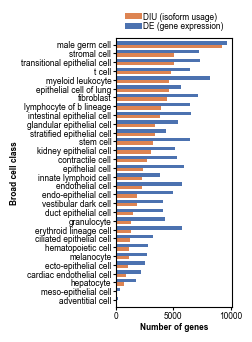

In [21]:
# Grouped VERTICAL bars, one column per broad cell class. Ordered by DIU count so the reading
# order left-to-right is "most isoform-regulated class first"; the DE bar beside it then shows
# whether that class simply has the most expression differences as well.
# NOTE ax.bar(x, height, width=...) -- its SECOND POSITIONAL is already `height`, so passing
# height=_h (the barh spelling) raises "got multiple values for argument 'height'". The bar
# thickness knob is `width` for bar and `height` for barh.
# _d = diu_de_per_ct.sort_values("DIU", ascending=False)   # bar fills left-to-right
# _x = np.arange(len(_d))
# _w = 0.38

# fig, ax = plt.subplots(figsize=(4.0, 1.2))               # flipped with the axes
# ax.bar(_x - _w / 2, _d["DIU"], width=_w, color="#dd8452", label="DIU (isoform usage)")
# ax.bar(_x + _w / 2, _d["DE"], width=_w, color="#4c72b0", label="DE (gene expression)")
# ax.set_xticks(_x)
# ax.set_xticklabels(_d.index, rotation=45, ha = "right")
# ax.set_xlim(-0.6, len(_d) - 0.4)
# ax.set_ylabel("Number of genes")
# ax.set_xlabel("Broad cell class")
# ax.legend(frameon=False, loc="upper right")
# fig.savefig(figpath("04_11_diu_vs_de_genes_per_cell_type.pdf"), bbox_inches="tight")
# plt.show()


# Grouped HORIZONTAL bars, one row per broad cell class.
# Ordered by DIU count so the most isoform-regulated class is at the top;
# the DE bar beside it shows whether that class also has the most expression differences.

_d = diu_de_per_ct.sort_values("DIU", ascending=True)
_y = np.arange(len(_d))
_h = 0.38

fig, ax = plt.subplots(figsize=(1.5, 3.5))

ax.barh(
    _y - _h / 2,
    _d["DIU"],
    height=_h,
    color="#dd8452",
    label="DIU (isoform usage)"
)

ax.barh(
    _y + _h / 2,
    _d["DE"],
    height=_h,
    color="#4c72b0",
    label="DE (gene expression)"
)

ax.set_yticks(_y)
ax.set_yticklabels(_d.index)

# Tiny space before the first bar and after the last bar
ax.set_ylim(-_h / 2 - 0.6, len(_d) - 1 + _h / 2 + 0.6)

ax.set_xlabel("Number of genes")
ax.set_ylabel("Broad cell class")

ax.legend(
    frameon=False,
    loc=8,
    bbox_to_anchor=(0.5, 1.0)
)

fig.savefig(
    figpath("04_11_diu_vs_de_genes_per_cell_type.pdf"),
    bbox_inches="tight"
)

plt.show()

250,159 (gene, cell class) pairs testable on both axes
  DE call: padj < 0.05 AND |log2FC| > 0.5
  DIU only    28,469  ( 11.4% of all pairs)
  both        53,470  ( 21.4% of all pairs)
  DE only     92,179  ( 36.8% of all pairs)
  neither     76,041  ( 30.4% of all pairs)

DIU total 81,939 | DE total 145,649 | overlap (both) 53,470
  34.7% of DIU events are in genes that are NOT DE
  65.3% of DIU events are also DE
  63.3% of DE events show no usage shift
  Jaccard(DIU, DE) = 0.307


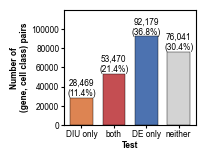

In [22]:
# The four-way breakdown behind the comparison above, pooled over cell classes: for each
# (gene, cell class) pair, is there signal in isoform USAGE only, in EXPRESSION only, in both,
# or in neither? Same partition the section-5b scatter colours, but on THIS section's DE call
# (padj < DE_PADJ AND |log2FC| > DE_LFC), shown as counts because overplotting on the
# scatter makes the DIU-only corner impossible to size by eye.
if "m" not in globals() or "quadrant" not in m.columns:
    raise NameError("run the section 9 compute cell first -- it builds `quadrant` from the "
                    "section-9 DE call (padj + fold change)")

_ORDER = ["DIU only", "both", "DE only", "neither"]
_QPAL = {"DIU only": "#dd8452", "both": "#c44e52", "DE only": "#4c72b0", "neither": "lightgrey"}
quad_counts = m["quadrant"].value_counts().reindex(_ORDER).fillna(0).astype(int)
_tot = int(quad_counts.sum())
_n_diu, _n_de = int(m["diu_sig"].sum()), int(m["de_sig"].sum())

print(f"{_tot:,} (gene, cell class) pairs testable on both axes")
print(f"  DE call: padj < {DE_PADJ} AND |log2FC| > {DE_LFC}")
for _q in _ORDER:
    print(f"  {_q:<9s} {quad_counts[_q]:>8,}  ({quad_counts[_q] / _tot * 100:5.1f}% of all pairs)")
print(f"\nDIU total {_n_diu:,} | DE total {_n_de:,} | overlap (both) {quad_counts['both']:,}")
print(f"  {quad_counts['DIU only'] / max(_n_diu, 1) * 100:.1f}% of DIU events are in genes that are NOT DE")
print(f"  {quad_counts['both'] / max(_n_diu, 1) * 100:.1f}% of DIU events are also DE")
print(f"  {quad_counts['DE only'] / max(_n_de, 1) * 100:.1f}% of DE events show no usage shift")
# Jaccard puts the overlap on a scale that is not dominated by the much larger DE set
_jac = quad_counts["both"] / max(_n_diu + _n_de - quad_counts["both"], 1)
print(f"  Jaccard(DIU, DE) = {_jac:.3f}")

fig, ax = plt.subplots(figsize=(1.7, 1.5))
_x = np.arange(len(_ORDER))
ax.bar(_x, quad_counts.values, width=0.7, color=[_QPAL[q] for q in _ORDER],
       edgecolor="black", linewidth=0.3)
for _xi, _v in zip(_x, quad_counts.values):
    ax.text(_xi, _v, f"{_v:,}\n({_v / _tot * 100:.1f}%)", ha="center", va="bottom", fontsize=6)
ax.set_xticks(_x)
ax.set_xticklabels(_ORDER)
ax.set_xlabel("Test")
ax.set_ylabel("Number of\n(gene, cell class) pairs")
ax.set_ylim(0, quad_counts.max() * 1.30)     # headroom so the two-line labels are not clipped
fig.savefig(figpath("04_11_diu_de_quadrant_counts.pdf"), bbox_inches="tight")
plt.show()

In [32]:
# --- DIU-only pairs that gene-level testing cannot see AT ALL -----------------------------
# "DIU only" above means DIU-significant and failing the JOINT DE call
# (de_padj < DE_PADJ AND |de_lfc| > DE_LFC). That pools two different things:
#
#   (a) the gene IS significantly DE, but its fold change sits below DE_LFC -- a THRESHOLD
#       MISS, recoverable simply by relaxing DE_LFC
#   (b) the gene is not DE at ANY fold change (de_padj >= DE_PADJ) -- invisible to a
#       gene-level test wherever the fold-change cut is placed
#
# Only (b) supports the manuscript's "invisible to gene-level testing". This cell separates
# them and ranks (b) by DIU effect size.
if "m" not in globals() or not {"diu_sig", "de_padj", "de_lfc", "max_abs_delta",
                                "quadrant"} <= set(m.columns):
    raise NameError("run the section 9 compute cell first -- it builds `m` with the "
                    "diu_sig / de_sig / quadrant columns")

_n_diu = int(m["diu_sig"].sum())
_diu_only = m[m["quadrant"] == "DIU only"]
_invisible = m[m["diu_sig"] & (m["de_padj"] >= DE_PADJ)].copy()
_thresh_miss = m[m["diu_sig"] & (m["de_padj"] < DE_PADJ) & (m["de_lfc"].abs() <= DE_LFC)]

print(f"DIU-significant pairs                            : {_n_diu:,}")
print(f"  'DIU only' (fails the joint DE call)           : {len(_diu_only):,}"
      f"   ({100 * len(_diu_only) / max(_n_diu, 1):.1f}% of DIU)")
print(f"    (a) DE-significant, |log2FC| <= {DE_LFC}          : {len(_thresh_miss):,}"
      f"   -- threshold miss")
print(f"    (b) NOT DE at any fold change                : {len(_invisible):,}"
      f"   ({100 * len(_invisible) / max(_n_diu, 1):.1f}% of DIU)  <- ranked below")
_med_inv = _invisible["de_lfc"].abs().median()
_med_all = m["de_lfc"].abs().median()
_med_miss = _thresh_miss["de_lfc"].abs().median()
_med_only = _diu_only["de_lfc"].abs().median()
print(f"    median |log2FC|  (b) not-DE-at-any-FC : {_med_inv:.3f}")
print(f"    median |log2FC|  (a) threshold miss   : {_med_miss:.3f}")
print(f"    median |log2FC|  (a)+(b) 'DIU only'   : {_med_only:.3f}")
print(f"    median |log2FC|  all tested pairs     : {_med_all:.3f}"
      f"   (DE floor is {DE_LFC})")

_split = len(_thresh_miss) + len(_invisible)
if _split != len(_diu_only):
    print(f"    NOTE: (a) + (b) = {_split:,} != {len(_diu_only):,}; the two groups should")
    print("    partition 'DIU only' exactly -- check for NaN in de_padj / de_lfc.")

# --- rank (b) by DIU effect size ---------------------------------------------------------
# max_abs_delta is the largest |change in isoform fraction| for that gene in that cell class,
# which is the quantity the DIU call itself thresholds at DIU_DELTA -- so ranking on it ranks
# by the same effect the test used, not by a proxy.
_cols = ["gene", "group", "max_abs_delta", "dm_padj", "de_lfc", "de_padj"]
_ranked = (_invisible.sort_values("max_abs_delta", ascending=False)[_cols]
           .reset_index(drop=True))
_ranked.to_csv("./../csvs/04_11_diu_only_not_de_ranked.csv", index=False)
print(f"\nwrote ./../csvs/04_11_diu_only_not_de_ranked.csv ({len(_ranked):,} pairs)")

print(f"\nTOP 10 (gene, cell class) pairs by |delta isoform fraction|:")
print(_ranked.head(10).to_string(index=False,
                                 float_format=lambda v: f"{v:.4g}"))

# Gene-level view: the same set collapsed to one row per gene, keeping its strongest class.
# A gene can be DIU-only in several classes, so the pair table above can repeat a symbol.
_by_gene = (_ranked.sort_values("max_abs_delta", ascending=False)
            .groupby("gene", as_index=False)
            .agg(best_class=("group", "first"),
                 max_abs_delta=("max_abs_delta", "max"),
                 dm_padj=("dm_padj", "min"),
                 n_classes=("group", "size"))
            .sort_values("max_abs_delta", ascending=False)
            .reset_index(drop=True))
print(f"\nTOP 10 GENES (collapsed over cell classes; {len(_by_gene):,} distinct genes):")
print(_by_gene.head(10).to_string(index=False,
                                  float_format=lambda v: f"{v:.4g}"))


DIU-significant pairs                            : 81,939
  'DIU only' (fails the joint DE call)           : 28,469   (34.7% of DIU)
    (a) DE-significant, |log2FC| <= 0.5          : 16,331   -- threshold miss
    (b) NOT DE at any fold change                : 12,138   (14.8% of DIU)  <- ranked below
    median |log2FC|  (b) not-DE-at-any-FC : 0.104
    median |log2FC|  (a) threshold miss   : 0.335
    median |log2FC|  (a)+(b) 'DIU only'   : 0.237
    median |log2FC|  all tested pairs     : 0.632   (DE floor is 0.5)

wrote ./../csvs/04_11_diu_only_not_de_ranked.csv (12,138 pairs)

TOP 10 (gene, cell class) pairs by |delta isoform fraction|:
           gene                        group  max_abs_delta    dm_padj   de_lfc  de_padj
          ABCC3               male germ cell         0.9968          0  -0.1535  0.08149
ENSG00000232934 transitional epithelial cell         0.9889  3.168e-77  -0.1571   0.4727
      LINC02384               male germ cell         0.9846  7.742e-92   0.3508  0.

In [24]:
# Case study: how one gene's isoform composition shifts across cell classes.
#
# Grouping MUST match the DM test, which ran groupby="broad_cell_class" (cell 8), so the
# mask below uses broad_cell_class.
CASE_GENES     = ['FBXL13']   # set to None to use the gene with the most DIU events
MIN_EXPRESSING = 5            # min cells expressing the gene for a class to be plotted
GROUP_NOVEL    = True         # collapse novel (PB.*) isoforms into one band
NOVEL_PREFIX   = "PB."        # novel ids have no ENST match, so they keep PB.X.Y
NOVEL_COLOR    = "lightgrey"  # colour of that band

gene_diu_counts = diu_df.groupby("gene").size().sort_values(ascending=False)
if CASE_GENES is None:
    # NOTE ranked by NUMBER of DIU events, not by effect size. The section-6 dotplot
    # ranks by delta_fraction, so these two lists need not agree.
    print("Top genes by number of DIU events:")
    print(gene_diu_counts.head(20))
    CASE_GENES = gene_diu_counts.head(1).index.tolist()
    print(f"CASE_GENES is None -> using top gene by DIU-event count: {CASE_GENES}")

frac_mat = adata.layers["isoform_fraction"]
gene_col_name = rank_gene_col

frac_df = None
plot_title = None
case_fig_name = None
novel_col = None
for gene in CASE_GENES:
    gene_mask = (adata.var[gene_col_name] == gene).values
    isoform_names = adata.var_names[gene_mask].tolist()
    if not len(isoform_names):
        plot_title = f"{gene}: no isoforms in this object"
        print(plot_title)
        continue

    # Mean over EXPRESSING cells only: a non-expressing cell has all-zero isoform
    # fractions, so including it would drag every bar toward zero and the stack would no
    # longer sum to 1. Note this differs from the section-6 dotplot, which averages over
    # ALL cells in the class -- the two panels answer different questions.
    ct_fracs, _skipped = {}, []
    for ct in top_cts:
        ct_mask = (adata.obs["broad_cell_class"] == ct).values
        _blk = frac_mat[ct_mask][:, gene_mask]     # NOT `sub` -- that name holds the
        if issparse(_blk):                         # AnnData built in section 6
            _blk = _blk.toarray()
        expressed = _blk.sum(axis=1) > 0
        if expressed.sum() >= MIN_EXPRESSING:
            ct_fracs[ct] = _blk[expressed, :].mean(axis=0)
        else:
            _skipped.append((ct, int(ct_mask.sum()), int(expressed.sum())))

    if _skipped:      # report rather than drop silently
        print(f"{gene}: {len(_skipped)} of {len(top_cts)} cell classes dropped "
              f"(<{MIN_EXPRESSING} expressing cells): "
              + ", ".join(f"{c} [{n} cells, {e} expr]" for c, n, e in _skipped))
    if not ct_fracs:
        plot_title = f"{gene}: no data"
        continue

    frac_df = pd.DataFrame(ct_fracs, index=isoform_names).T

    # Collapse novel isoforms into a single band. Known isoforms carry an ENST id; novel
    # ones (NIC/NNC) keep their PB.X.Y collapse id, so the prefix is the test. Summing
    # their fractions is valid -- they are parts of the same gene's composition.
    if GROUP_NOVEL:
        _nov = [c for c in frac_df.columns if str(c).startswith(NOVEL_PREFIX)]
        if _nov:
            novel_col = f"Novel ({len(_nov)})"
            _novel_sum = frac_df[_nov].sum(axis=1)
            frac_df = frac_df.drop(columns=_nov)
            frac_df[novel_col] = _novel_sum          # appended last -> top of the stack
            print(f"{gene}: grouped {len(_nov)} novel {NOVEL_PREFIX}* isoforms "
                  f"into '{novel_col}' ({len(frac_df.columns) - 1} known shown separately)")
    plot_title = f"{gene} ({len(isoform_names)} isoforms)"
    case_fig_name = f"04_11_case_study_{gene}.pdf"
    print(f"{gene}: plotted across {len(frac_df)} of {len(top_cts)} broad cell classes")

FBXL13: 10 of 30 cell classes dropped (<5 expressing cells): intestinal epithelial cell [5126 cells, 1 expr], stratified epithelial cell [1665 cells, 1 expr], erythroid lineage cell [8520 cells, 1 expr], granulocyte [3106 cells, 2 expr], hematopoietic cell [1393 cells, 1 expr], ecto-epithelial cell [603 cells, 4 expr], cardiac endothelial cell [965 cells, 1 expr], hepatocyte [571 cells, 0 expr], meso-epithelial cell [155 cells, 0 expr], adventitial cell [108 cells, 0 expr]
FBXL13: grouped 20 novel PB.* isoforms into 'Novel (20)' (8 known shown separately)
FBXL13: plotted across 20 of 30 broad cell classes


FBXL13: 15 of 20 classes below 1.0% expressing, dropped from both panels: transitional epithelial cell [0.27%, 24/8751], stromal cell [0.29%, 66/22865], epithelial cell of lung [0.22%, 12/5366], t cell [0.15%, 20/13272], myeloid leukocyte [0.07%, 17/25558], fibroblast [0.20%, 54/26766], lymphocyte of b lineage [0.13%, 15/11723], kidney epithelial cell [0.37%, 14/3775], glandular epithelial cell [0.32%, 16/5062], stem cell [0.10%, 17/17088], epithelial cell [0.76%, 30/3930], endothelial cell [0.25%, 25/10055], innate lymphoid cell [0.17%, 5/3004], duct epithelial cell [0.71%, 7/981], melanocyte [0.66%, 5/762]


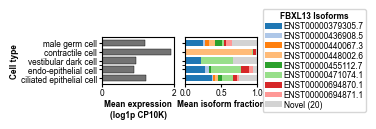

FBXL13: 5 of 20 classes plotted, in the composition panel's order
                              mean_log1p_cp10k  mean_log1p_cp10k_all_cells  pct_expressing  n_expressing  n_cells  shown
broad_cell_class                                                                                                        
male germ cell                           1.202                       0.284          23.582          1568     6649   True
transitional epithelial cell             1.204                       0.003           0.274            24     8751  False
stromal cell                             1.869                       0.005           0.289            66    22865  False
epithelial cell of lung                  1.167                       0.003           0.224            12     5366  False
t cell                                   2.012                       0.003           0.151            20    13272  False
myeloid leukocyte                        1.426                       0.001           0.

In [25]:
# --- companion panels: GENE-LEVEL EXPRESSION, and the composition over the same classes ---
# The stacked bar above shows isoform COMPOSITION, which is scale-free by construction: it
# sums to 1 in every class whether the gene is highly expressed there or barely detected.
# The LEFT panel supplies the missing axis -- how much of the gene there is -- and the RIGHT
# panel redraws the composition over exactly the classes that survive the expression floor,
# so a switch and the level it happens at can be read off one shared set of rows.
#
# THREE DIFFERENCES FROM THE PANEL ABOVE, all deliberate:
#   1. It averages over EXPRESSING CELLS ONLY (gene counts > 0), which is the same cell set
#      the composition panel uses -- an isoform fraction is undefined in a cell holding no
#      molecules of the gene, so that panel is conditional by construction. Both panels
#      share a denominator class by class, and a switch can be read against the level in the
#      very cells that show it. Nothing is lost: the previous all-cell mean is still returned
#      as `mean_log1p_cp10k_all_cells`, and it is EXACTLY this column times pct_expressing/100,
#      because a non-expressing cell contributes log1p(0) = 0 to the sum and only enlarges the
#      denominator. That identity is why the old panel confounded level with detection rate.
#   2. adata.X is RAW transcript counts and 04_11 normalises nowhere, so this normalises
#      here: CP10K on each cell's total in THIS object, then log1p -- the same scale
#      rank_genes_groups used for the DE calls this notebook compares against.
#   3. A class must have at least MIN_PCT_EXPRESSING percent of its cells expressing the gene
#      to appear in EITHER panel. This is a RATE floor and is not the same test as cell 36's
#      MIN_EXPRESSING = 5, which is an absolute count: 5 expressing cells out of 2,000 clears
#      the count floor and fails this one. Classes dropped here are named with their rate, so
#      the filter never removes a class silently.
MIN_PCT_EXPRESSING = 1.0     # percent of a class's cells that must express the gene


def case_expression_panel(gene, classes, fname=None, figsize=None, frac=None,
                          novel_col_name=None, novel_color="lightgrey",
                          min_pct_expressing=MIN_PCT_EXPRESSING):
    """Expression (left) and isoform composition (right) over the classes clearing the floor.

    Bars are HORIZONTAL: cell classes run down the shared y-axis, values along x.

    `frac` is the composition frame built in the compute cell (rows = broad cell class,
    columns = isoform, novel already collapsed). Pass it to get the right-hand panel;
    omit it and only the expression panel is drawn.

    `figsize=None` sizes the figure automatically -- fixed width, height scaling with the
    number of classes that survive the floor. Pass a tuple to override exactly.
    """
    gmask = (adata.var[gene_col_name] == gene).values
    if not gmask.any():
        print(f"{gene}: no transcripts in this object")
        return None
    _X = adata.X
    _tot = np.asarray(_X.sum(axis=1)).ravel().astype(float)
    _g = np.asarray(_X[:, gmask].sum(axis=1)).ravel().astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        _expr = np.log1p(np.where(_tot > 0, _g / _tot * 1e4, 0.0))
    _bcc = adata.obs["broad_cell_class"].values
    _expressing = _g > 0

    rows = []
    for ct in classes:
        m_ = (_bcc == ct)
        if not m_.any():
            continue
        m_expr = m_ & _expressing
        n_expr = int(m_expr.sum())
        rows.append({"broad_cell_class": ct,
                     # NaN, not 0, when a class has no expressing cell: an empty slot rather
                     # than a floor value. Such a class cannot clear the rate floor anyway.
                     "mean_log1p_cp10k": float(_expr[m_expr].mean()) if n_expr else np.nan,
                     "mean_log1p_cp10k_all_cells": float(_expr[m_].mean()),
                     "pct_expressing": float(100.0 * _expressing[m_].mean()),
                     "n_expressing": n_expr,
                     "n_cells": int(m_.sum())})
    if not rows:
        print(f"{gene}: none of the requested classes are present")
        return None
    d_all = pd.DataFrame(rows).set_index("broad_cell_class").reindex(
        [c for c in classes if c in {r["broad_cell_class"] for r in rows}])

    # --- expression-rate floor, applied to BOTH panels so they keep the same rows ----------
    d_all["shown"] = d_all["pct_expressing"] >= min_pct_expressing
    _dropped, d = d_all[~d_all["shown"]], d_all[d_all["shown"]]
    if len(_dropped):
        print(f"{gene}: {len(_dropped)} of {len(d_all)} classes below {min_pct_expressing}% "
              f"expressing, dropped from both panels: "
              + ", ".join(f"{c} [{r.pct_expressing:.2f}%, {int(r.n_expressing)}/{int(r.n_cells)}]"
                          for c, r in _dropped.iterrows()))
    if not len(d):
        print(f"{gene}: no class clears {min_pct_expressing}% expressing -- nothing to plot")
        return d_all

    _sub = None if frac is None else frac.reindex(d.index)
    _two = _sub is not None and len(_sub.columns) > 0

    # horizontal layout: width is fixed, height tracks the class count so bar thickness
    # stays constant however many classes survive the floor
    if figsize is None:
        figsize = (2.0, 0.6)
    # sharey pins both panels to one class axis and hides the right panel's duplicate
    # labels, so the gap between panels can stay small
    fig, _axes = plt.subplots(1, 2 if _two else 1, figsize=figsize, sharey=_two,
                              gridspec_kw={"wspace": 0.15} if _two else None)
    _axes = np.atleast_1d(_axes)
    ax = _axes[0]

    _y = np.arange(len(d))
    ax.barh(_y, d["mean_log1p_cp10k"].values, height=0.7,
            color="0.45", edgecolor="black", linewidth=0.3)
    ax.set_yticks(_y)
    ax.set_yticklabels(d.index)
    ax.set_ylabel("Cell type")
    ax.set_xlabel(f"Mean expression\n(log1p CP10K)")
    # ax.set_title(f"{gene} expression (expressing cells)")
    ax.tick_params(length=TICK_LEN if "TICK_LEN" in globals() else 2.0)

    if _two:
        # Every row is already a within-class proportion summing to 1, so dropping classes
        # changes NO bar -- this is the panel above with the sub-1% classes removed, not a
        # recomputation. Renormalising across classes would be meaningless here.
        axR = _axes[1]
        _pal, _k, _colors = plt.get_cmap("tab20"), 0, []
        for _c in _sub.columns:
            if novel_col_name is not None and _c == novel_col_name:
                _colors.append(novel_color)
            else:
                _colors.append(_pal(_k % 20))
                _k += 1
        # pandas keeps `width` as the bar-thickness kwarg even for barh
        _sub.plot(kind="barh", stacked=True, ax=axR, legend=False, color=_colors,
                  width=0.7)
        axR.set_ylabel("")   # pandas stamps the index name here; sharey hides the ticks anyway
        axR.set_xlabel(f"Mean isoform fraction")
        # axR.set_title(f"{gene} composition")
        axR.set_xlim(0, 1)
        axR.tick_params(length=TICK_LEN if "TICK_LEN" in globals() else 2.0)
        axR.legend(ncol=1, bbox_to_anchor=(1.02, 0.5), loc=6, fontsize=6, title = f"{gene} Isoforms")

    # barh puts row 0 at the BOTTOM; flip so classes read top-to-bottom in the composition
    # panel's order (with sharey this single call inverts both panels together)
    ax.invert_yaxis()

    plt.savefig(figpath(fname or f"04_11_case_study_{gene}_expression.pdf"), dpi=300)
    plt.show()

    print(f"{gene}: {len(d)} of {len(d_all)} classes plotted, in the composition panel's order")
    print(d_all.round(3).to_string())
    print("Both panels are conditioned on expressing cells and share one class axis, so a")
    print("row means the same thing in each. mean_log1p_cp10k_all_cells is the former")
    print("all-cell mean, exactly mean_log1p_cp10k times pct_expressing/100. Classes with")
    print("shown=False failed the rate floor; read n_expressing before trusting a thin one.")
    return d_all


# same gene and the same classes the composition panel actually drew (frac_df.index); the
# composition is passed through so the right-hand panel is that panel restricted, not rebuilt
if frac_df is not None:
    _case_expr = case_expression_panel(CASE_GENES[0], list(frac_df.index), frac=frac_df,
                                       novel_col_name=novel_col, novel_color=NOVEL_COLOR)
else:
    print("frac_df is None -- run the compute cell above first")

In [26]:
# Case study: how one gene's isoform composition shifts across cell classes.
#
# Grouping MUST match the DM test, which ran groupby="broad_cell_class" (cell 8), so the
# mask below uses broad_cell_class.
CASE_GENES     = ['S100A16']   # set to None to use the gene with the most DIU events
MIN_EXPRESSING = 5            # min cells expressing the gene for a class to be plotted
GROUP_NOVEL    = True         # collapse novel (PB.*) isoforms into one band
NOVEL_PREFIX   = "PB."        # novel ids have no ENST match, so they keep PB.X.Y
NOVEL_COLOR    = "lightgrey"  # colour of that band

gene_diu_counts = diu_df.groupby("gene").size().sort_values(ascending=False)
if CASE_GENES is None:
    # NOTE ranked by NUMBER of DIU events, not by effect size. The section-6 dotplot
    # ranks by delta_fraction, so these two lists need not agree.
    print("Top genes by number of DIU events:")
    print(gene_diu_counts.head(20))
    CASE_GENES = gene_diu_counts.head(1).index.tolist()
    print(f"CASE_GENES is None -> using top gene by DIU-event count: {CASE_GENES}")

frac_mat = adata.layers["isoform_fraction"]
gene_col_name = rank_gene_col

frac_df = None
plot_title = None
case_fig_name = None
novel_col = None
for gene in CASE_GENES:
    gene_mask = (adata.var[gene_col_name] == gene).values
    isoform_names = adata.var_names[gene_mask].tolist()
    if not len(isoform_names):
        plot_title = f"{gene}: no isoforms in this object"
        print(plot_title)
        continue

    # Mean over EXPRESSING cells only: a non-expressing cell has all-zero isoform
    # fractions, so including it would drag every bar toward zero and the stack would no
    # longer sum to 1. Note this differs from the section-6 dotplot, which averages over
    # ALL cells in the class -- the two panels answer different questions.
    ct_fracs, _skipped = {}, []
    for ct in top_cts:
        ct_mask = (adata.obs["broad_cell_class"] == ct).values
        _blk = frac_mat[ct_mask][:, gene_mask]     # NOT `sub` -- that name holds the
        if issparse(_blk):                         # AnnData built in section 6
            _blk = _blk.toarray()
        expressed = _blk.sum(axis=1) > 0
        if expressed.sum() >= MIN_EXPRESSING:
            ct_fracs[ct] = _blk[expressed, :].mean(axis=0)
        else:
            _skipped.append((ct, int(ct_mask.sum()), int(expressed.sum())))

    if _skipped:      # report rather than drop silently
        print(f"{gene}: {len(_skipped)} of {len(top_cts)} cell classes dropped "
              f"(<{MIN_EXPRESSING} expressing cells): "
              + ", ".join(f"{c} [{n} cells, {e} expr]" for c, n, e in _skipped))
    if not ct_fracs:
        plot_title = f"{gene}: no data"
        continue

    frac_df = pd.DataFrame(ct_fracs, index=isoform_names).T

    # Collapse novel isoforms into a single band. Known isoforms carry an ENST id; novel
    # ones (NIC/NNC) keep their PB.X.Y collapse id, so the prefix is the test. Summing
    # their fractions is valid -- they are parts of the same gene's composition.
    if GROUP_NOVEL:
        _nov = [c for c in frac_df.columns if str(c).startswith(NOVEL_PREFIX)]
        if _nov:
            novel_col = f"Novel ({len(_nov)})"
            _novel_sum = frac_df[_nov].sum(axis=1)
            frac_df = frac_df.drop(columns=_nov)
            frac_df[novel_col] = _novel_sum          # appended last -> top of the stack
            print(f"{gene}: grouped {len(_nov)} novel {NOVEL_PREFIX}* isoforms "
                  f"into '{novel_col}' ({len(frac_df.columns) - 1} known shown separately)")
    plot_title = f"{gene} ({len(isoform_names)} isoforms)"
    case_fig_name = f"04_11_case_study_{gene}.pdf"
    print(f"{gene}: plotted across {len(frac_df)} of {len(top_cts)} broad cell classes")

S100A16: grouped 42 novel PB.* isoforms into 'Novel (42)' (5 known shown separately)
S100A16: plotted across 30 of 30 broad cell classes


S100A16: 5 of 30 classes below 1.0% expressing, dropped from both panels: t cell [0.83%, 110/13272], lymphocyte of b lineage [0.68%, 80/11723], innate lymphoid cell [0.17%, 5/3004], erythroid lineage cell [0.81%, 69/8520], granulocyte [0.52%, 16/3106]


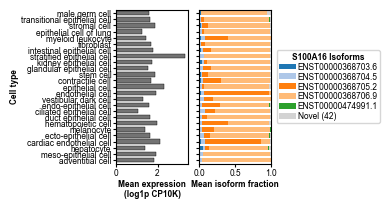

S100A16: 25 of 30 classes plotted, in the composition panel's order
                              mean_log1p_cp10k  mean_log1p_cp10k_all_cells  pct_expressing  n_expressing  n_cells  shown
broad_cell_class                                                                                                        
male germ cell                           1.608                       0.018           1.098            73     6649   True
transitional epithelial cell             1.657                       0.792          47.766          4180     8751   True
stromal cell                             1.891                       0.308          16.296          3726    22865   True
epithelial cell of lung                  1.265                       0.329          26.034          1397     5366   True
t cell                                   2.116                       0.018           0.829           110    13272  False
myeloid leukocyte                        1.419                       0.017           

In [27]:
# --- companion panels: GENE-LEVEL EXPRESSION, and the composition over the same classes ---
# The stacked bar above shows isoform COMPOSITION, which is scale-free by construction: it
# sums to 1 in every class whether the gene is highly expressed there or barely detected.
# The LEFT panel supplies the missing axis -- how much of the gene there is -- and the RIGHT
# panel redraws the composition over exactly the classes that survive the expression floor,
# so a switch and the level it happens at can be read off one shared set of rows.
#
# THREE DIFFERENCES FROM THE PANEL ABOVE, all deliberate:
#   1. It averages over EXPRESSING CELLS ONLY (gene counts > 0), which is the same cell set
#      the composition panel uses -- an isoform fraction is undefined in a cell holding no
#      molecules of the gene, so that panel is conditional by construction. Both panels
#      share a denominator class by class, and a switch can be read against the level in the
#      very cells that show it. Nothing is lost: the previous all-cell mean is still returned
#      as `mean_log1p_cp10k_all_cells`, and it is EXACTLY this column times pct_expressing/100,
#      because a non-expressing cell contributes log1p(0) = 0 to the sum and only enlarges the
#      denominator. That identity is why the old panel confounded level with detection rate.
#   2. adata.X is RAW transcript counts and 04_11 normalises nowhere, so this normalises
#      here: CP10K on each cell's total in THIS object, then log1p -- the same scale
#      rank_genes_groups used for the DE calls this notebook compares against.
#   3. A class must have at least MIN_PCT_EXPRESSING percent of its cells expressing the gene
#      to appear in EITHER panel. This is a RATE floor and is not the same test as cell 36's
#      MIN_EXPRESSING = 5, which is an absolute count: 5 expressing cells out of 2,000 clears
#      the count floor and fails this one. Classes dropped here are named with their rate, so
#      the filter never removes a class silently.
MIN_PCT_EXPRESSING = 1.0     # percent of a class's cells that must express the gene


def case_expression_panel(gene, classes, fname=None, figsize=None, frac=None,
                          novel_col_name=None, novel_color="lightgrey",
                          min_pct_expressing=MIN_PCT_EXPRESSING):
    """Expression (left) and isoform composition (right) over the classes clearing the floor.

    Bars are HORIZONTAL: cell classes run down the shared y-axis, values along x.

    `frac` is the composition frame built in the compute cell (rows = broad cell class,
    columns = isoform, novel already collapsed). Pass it to get the right-hand panel;
    omit it and only the expression panel is drawn.

    `figsize=None` sizes the figure automatically -- fixed width, height scaling with the
    number of classes that survive the floor. Pass a tuple to override exactly.
    """
    gmask = (adata.var[gene_col_name] == gene).values
    if not gmask.any():
        print(f"{gene}: no transcripts in this object")
        return None
    _X = adata.X
    _tot = np.asarray(_X.sum(axis=1)).ravel().astype(float)
    _g = np.asarray(_X[:, gmask].sum(axis=1)).ravel().astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        _expr = np.log1p(np.where(_tot > 0, _g / _tot * 1e4, 0.0))
    _bcc = adata.obs["broad_cell_class"].values
    _expressing = _g > 0

    rows = []
    for ct in classes:
        m_ = (_bcc == ct)
        if not m_.any():
            continue
        m_expr = m_ & _expressing
        n_expr = int(m_expr.sum())
        rows.append({"broad_cell_class": ct,
                     # NaN, not 0, when a class has no expressing cell: an empty slot rather
                     # than a floor value. Such a class cannot clear the rate floor anyway.
                     "mean_log1p_cp10k": float(_expr[m_expr].mean()) if n_expr else np.nan,
                     "mean_log1p_cp10k_all_cells": float(_expr[m_].mean()),
                     "pct_expressing": float(100.0 * _expressing[m_].mean()),
                     "n_expressing": n_expr,
                     "n_cells": int(m_.sum())})
    if not rows:
        print(f"{gene}: none of the requested classes are present")
        return None
    d_all = pd.DataFrame(rows).set_index("broad_cell_class").reindex(
        [c for c in classes if c in {r["broad_cell_class"] for r in rows}])

    # --- expression-rate floor, applied to BOTH panels so they keep the same rows ----------
    d_all["shown"] = d_all["pct_expressing"] >= min_pct_expressing
    _dropped, d = d_all[~d_all["shown"]], d_all[d_all["shown"]]
    if len(_dropped):
        print(f"{gene}: {len(_dropped)} of {len(d_all)} classes below {min_pct_expressing}% "
              f"expressing, dropped from both panels: "
              + ", ".join(f"{c} [{r.pct_expressing:.2f}%, {int(r.n_expressing)}/{int(r.n_cells)}]"
                          for c, r in _dropped.iterrows()))
    if not len(d):
        print(f"{gene}: no class clears {min_pct_expressing}% expressing -- nothing to plot")
        return d_all

    _sub = None if frac is None else frac.reindex(d.index)
    _two = _sub is not None and len(_sub.columns) > 0

    # horizontal layout: width is fixed, height tracks the class count so bar thickness
    # stays constant however many classes survive the floor
    if figsize is None:
        figsize = (2.0, 2.0)
    # sharey pins both panels to one class axis and hides the right panel's duplicate
    # labels, so the gap between panels can stay small
    fig, _axes = plt.subplots(1, 2 if _two else 1, figsize=figsize, sharey=_two,
                              gridspec_kw={"wspace": 0.15} if _two else None)
    _axes = np.atleast_1d(_axes)
    ax = _axes[0]

    _y = np.arange(len(d))
    ax.barh(_y, d["mean_log1p_cp10k"].values, height=0.7,
            color="0.45", edgecolor="black", linewidth=0.3)
    ax.set_yticks(_y)
    ax.set_yticklabels(d.index)
    ax.set_ylabel("Cell type")
    ax.set_xlabel(f"Mean expression\n(log1p CP10K)")
    # ax.set_title(f"{gene} expression (expressing cells)")
    ax.tick_params(length=TICK_LEN if "TICK_LEN" in globals() else 2.0)

    if _two:
        # Every row is already a within-class proportion summing to 1, so dropping classes
        # changes NO bar -- this is the panel above with the sub-1% classes removed, not a
        # recomputation. Renormalising across classes would be meaningless here.
        axR = _axes[1]
        _pal, _k, _colors = plt.get_cmap("tab20"), 0, []
        for _c in _sub.columns:
            if novel_col_name is not None and _c == novel_col_name:
                _colors.append(novel_color)
            else:
                _colors.append(_pal(_k % 20))
                _k += 1
        # pandas keeps `width` as the bar-thickness kwarg even for barh
        _sub.plot(kind="barh", stacked=True, ax=axR, legend=False, color=_colors,
                  width=0.7)
        axR.set_ylabel("")   # pandas stamps the index name here; sharey hides the ticks anyway
        axR.set_xlabel(f"Mean isoform fraction")
        # axR.set_title(f"{gene} composition")
        axR.set_xlim(0, 1)
        axR.tick_params(length=TICK_LEN if "TICK_LEN" in globals() else 2.0)
        axR.legend(ncol=1, bbox_to_anchor=(1.02, 0.5), loc=6, fontsize=6, title = f"{gene} Isoforms")

    # barh puts row 0 at the BOTTOM; flip so classes read top-to-bottom in the composition
    # panel's order (with sharey this single call inverts both panels together)
    ax.invert_yaxis()

    plt.savefig(figpath(fname or f"04_11_case_study_{gene}_expression.pdf"), dpi=300)
    plt.show()

    print(f"{gene}: {len(d)} of {len(d_all)} classes plotted, in the composition panel's order")
    print(d_all.round(3).to_string())
    print("Both panels are conditioned on expressing cells and share one class axis, so a")
    print("row means the same thing in each. mean_log1p_cp10k_all_cells is the former")
    print("all-cell mean, exactly mean_log1p_cp10k times pct_expressing/100. Classes with")
    print("shown=False failed the rate floor; read n_expressing before trusting a thin one.")
    return d_all


# same gene and the same classes the composition panel actually drew (frac_df.index); the
# composition is passed through so the right-hand panel is that panel restricted, not rebuilt
if frac_df is not None:
    _case_expr = case_expression_panel(CASE_GENES[0], list(frac_df.index), frac=frac_df,
                                       novel_col_name=novel_col, novel_color=NOVEL_COLOR)
else:
    print("frac_df is None -- run the compute cell above first")

#10. Case studies: top genes with isoform switching

In [28]:
# # Case study: how one gene's isoform composition shifts across cell classes.
# #
# # Grouping MUST match the DM test, which ran groupby="broad_cell_class" (cell 8), so the
# # mask below uses broad_cell_class. It previously masked cell_ontology_class while
# # iterating top_cts, which holds BROAD names: 13 of the 40 broad names have no fine
# # equivalent, so they matched zero cells and were dropped silently, and the classes that
# # did appear were fine cell types that merely share a name with a broad class.
# CASE_GENES     = ['S100A16']   # set to None to use the gene with the most DIU events
# MIN_EXPRESSING = 5            # min cells expressing the gene for a class to be plotted
# GROUP_NOVEL    = True         # collapse novel (PB.*) isoforms into one band
# NOVEL_PREFIX   = "PB."        # novel ids have no ENST match, so they keep PB.X.Y
# NOVEL_COLOR    = "lightgrey"  # colour of that band

# gene_diu_counts = diu_df.groupby("gene").size().sort_values(ascending=False)
# if CASE_GENES is None:
#     # NOTE ranked by NUMBER of DIU events, not by effect size. The section-6 dotplot
#     # ranks by delta_fraction, so these two lists need not agree.
#     print("Top genes by number of DIU events:")
#     print(gene_diu_counts.head(20))
#     CASE_GENES = gene_diu_counts.head(1).index.tolist()
#     print(f"CASE_GENES is None -> using top gene by DIU-event count: {CASE_GENES}")

# frac_mat = adata.layers["isoform_fraction"]
# gene_col_name = rank_gene_col

# frac_df = None
# plot_title = None
# case_fig_name = None
# novel_col = None
# for gene in CASE_GENES:
#     gene_mask = (adata.var[gene_col_name] == gene).values
#     isoform_names = adata.var_names[gene_mask].tolist()
#     if not len(isoform_names):
#         plot_title = f"{gene}: no isoforms in this object"
#         print(plot_title)
#         continue

#     # Mean over EXPRESSING cells only: a non-expressing cell has all-zero isoform
#     # fractions, so including it would drag every bar toward zero and the stack would no
#     # longer sum to 1. Note this differs from the section-6 dotplot, which averages over
#     # ALL cells in the class -- the two panels answer different questions.
#     ct_fracs, _skipped = {}, []
#     for ct in top_cts:
#         ct_mask = (adata.obs["broad_cell_class"] == ct).values
#         _blk = frac_mat[ct_mask][:, gene_mask]     # NOT `sub` -- that name holds the
#         if issparse(_blk):                         # AnnData built in section 6
#             _blk = _blk.toarray()
#         expressed = _blk.sum(axis=1) > 0
#         if expressed.sum() >= MIN_EXPRESSING:
#             ct_fracs[ct] = _blk[expressed, :].mean(axis=0)
#         else:
#             _skipped.append((ct, int(ct_mask.sum()), int(expressed.sum())))

#     if _skipped:      # report rather than drop silently
#         print(f"{gene}: {len(_skipped)} of {len(top_cts)} cell classes dropped "
#               f"(<{MIN_EXPRESSING} expressing cells): "
#               + ", ".join(f"{c} [{n} cells, {e} expr]" for c, n, e in _skipped))
#     if not ct_fracs:
#         plot_title = f"{gene}: no data"
#         continue

#     frac_df = pd.DataFrame(ct_fracs, index=isoform_names).T

#     # Collapse novel isoforms into a single band. Known isoforms carry an ENST id; novel
#     # ones (NIC/NNC) keep their PB.X.Y collapse id, so the prefix is the test. Summing
#     # their fractions is valid -- they are parts of the same gene's composition.
#     if GROUP_NOVEL:
#         _nov = [c for c in frac_df.columns if str(c).startswith(NOVEL_PREFIX)]
#         if _nov:
#             novel_col = f"Novel ({len(_nov)})"
#             _novel_sum = frac_df[_nov].sum(axis=1)
#             frac_df = frac_df.drop(columns=_nov)
#             frac_df[novel_col] = _novel_sum          # appended last -> top of the stack
#             print(f"{gene}: grouped {len(_nov)} novel {NOVEL_PREFIX}* isoforms "
#                   f"into '{novel_col}' ({len(frac_df.columns) - 1} known shown separately)")
#     plot_title = f"{gene} ({len(isoform_names)} isoforms)"
#     case_fig_name = f"04_11_case_study_{gene}.pdf"
#     print(f"{gene}: plotted across {len(frac_df)} of {len(top_cts)} broad cell classes")

In [29]:
# fig, ax = plt.subplots(1, 1, figsize=(2.8, 1.2))
# if frac_df is not None:
#     # novel band grey, known isoforms cycle the default palette
#     _pal, _k, _colors = plt.get_cmap("tab20"), 0, []
#     for _c in frac_df.columns:
#         if novel_col is not None and _c == novel_col:
#             _colors.append(NOVEL_COLOR)
#         else:
#             _colors.append(_pal(_k % 20))
#             _k += 1
#     frac_df.plot(kind="bar", stacked=True, ax=ax, legend=False, color=_colors)
#     ax.set_title(plot_title)
#     ax.set_ylabel("Mean isoform fraction")
#     ax.legend(ncol = 1, bbox_to_anchor=(1.00, 0.5), loc=6, fontsize=6)
# else:
#     ax.set_title(plot_title)
# plt.savefig(figpath(case_fig_name or "04_11_case_study.pdf"))
# plt.show()

In [30]:
# # Case study: how one gene's isoform composition shifts across cell classes.
# #
# # Grouping MUST match the DM test, which ran groupby="broad_cell_class" (cell 8), so the
# # mask below uses broad_cell_class. It previously masked cell_ontology_class while
# # iterating top_cts, which holds BROAD names: 13 of the 40 broad names have no fine
# # equivalent, so they matched zero cells and were dropped silently, and the classes that
# # did appear were fine cell types that merely share a name with a broad class.
# CASE_GENES     = ['FBXL13']   # set to None to use the gene with the most DIU events
# MIN_EXPRESSING = 5            # min cells expressing the gene for a class to be plotted
# GROUP_NOVEL    = True         # collapse novel (PB.*) isoforms into one band
# NOVEL_PREFIX   = "PB."        # novel ids have no ENST match, so they keep PB.X.Y
# NOVEL_COLOR    = "lightgrey"  # colour of that band

# gene_diu_counts = diu_df.groupby("gene").size().sort_values(ascending=False)
# if CASE_GENES is None:
#     # NOTE ranked by NUMBER of DIU events, not by effect size. The section-6 dotplot
#     # ranks by delta_fraction, so these two lists need not agree.
#     print("Top genes by number of DIU events:")
#     print(gene_diu_counts.head(20))
#     CASE_GENES = gene_diu_counts.head(1).index.tolist()
#     print(f"CASE_GENES is None -> using top gene by DIU-event count: {CASE_GENES}")

# frac_mat = adata.layers["isoform_fraction"]
# gene_col_name = rank_gene_col

# frac_df = None
# plot_title = None
# case_fig_name = None
# novel_col = None
# for gene in CASE_GENES:
#     gene_mask = (adata.var[gene_col_name] == gene).values
#     isoform_names = adata.var_names[gene_mask].tolist()
#     if not len(isoform_names):
#         plot_title = f"{gene}: no isoforms in this object"
#         print(plot_title)
#         continue

#     # Mean over EXPRESSING cells only: a non-expressing cell has all-zero isoform
#     # fractions, so including it would drag every bar toward zero and the stack would no
#     # longer sum to 1. Note this differs from the section-6 dotplot, which averages over
#     # ALL cells in the class -- the two panels answer different questions.
#     ct_fracs, _skipped = {}, []
#     for ct in top_cts:
#         ct_mask = (adata.obs["broad_cell_class"] == ct).values
#         _blk = frac_mat[ct_mask][:, gene_mask]     # NOT `sub` -- that name holds the
#         if issparse(_blk):                         # AnnData built in section 6
#             _blk = _blk.toarray()
#         expressed = _blk.sum(axis=1) > 0
#         if expressed.sum() >= MIN_EXPRESSING:
#             ct_fracs[ct] = _blk[expressed, :].mean(axis=0)
#         else:
#             _skipped.append((ct, int(ct_mask.sum()), int(expressed.sum())))

#     if _skipped:      # report rather than drop silently
#         print(f"{gene}: {len(_skipped)} of {len(top_cts)} cell classes dropped "
#               f"(<{MIN_EXPRESSING} expressing cells): "
#               + ", ".join(f"{c} [{n} cells, {e} expr]" for c, n, e in _skipped))
#     if not ct_fracs:
#         plot_title = f"{gene}: no data"
#         continue

#     frac_df = pd.DataFrame(ct_fracs, index=isoform_names).T

#     # Collapse novel isoforms into a single band. Known isoforms carry an ENST id; novel
#     # ones (NIC/NNC) keep their PB.X.Y collapse id, so the prefix is the test. Summing
#     # their fractions is valid -- they are parts of the same gene's composition.
#     if GROUP_NOVEL:
#         _nov = [c for c in frac_df.columns if str(c).startswith(NOVEL_PREFIX)]
#         if _nov:
#             novel_col = f"Novel ({len(_nov)})"
#             _novel_sum = frac_df[_nov].sum(axis=1)
#             frac_df = frac_df.drop(columns=_nov)
#             frac_df[novel_col] = _novel_sum          # appended last -> top of the stack
#             print(f"{gene}: grouped {len(_nov)} novel {NOVEL_PREFIX}* isoforms "
#                   f"into '{novel_col}' ({len(frac_df.columns) - 1} known shown separately)")
#     plot_title = f"{gene} ({len(isoform_names)} isoforms)"
#     case_fig_name = f"04_11_case_study_{gene}.pdf"
#     print(f"{gene}: plotted across {len(frac_df)} of {len(top_cts)} broad cell classes")

In [31]:
# fig, ax = plt.subplots(1, 1, figsize=(2.0, 1.2))
# if frac_df is not None:
#     # novel band grey, known isoforms cycle the default palette
#     _pal, _k, _colors = plt.get_cmap("tab20"), 0, []
#     for _c in frac_df.columns:
#         if novel_col is not None and _c == novel_col:
#             _colors.append(NOVEL_COLOR)
#         else:
#             _colors.append(_pal(_k % 20))
#             _k += 1
#     frac_df.plot(kind="bar", stacked=True, ax=ax, legend=False, color=_colors)
#     ax.set_title(plot_title)
#     ax.set_ylabel("Mean isoform fraction")
#     ax.legend(ncol = 1, bbox_to_anchor=(1.02, 0.5), loc=6, fontsize=6)
# else:
#     ax.set_title(plot_title)
# plt.savefig(figpath(case_fig_name or "04_11_case_study.pdf"))
# plt.show()